# FLoRA Experiment Results Analysis

This notebook analyzes the results of replicated FLoRA experiments from the paper:
> **FLoRA: Federated Fine-Tuning Large Language Models with Heterogeneous Low-Rank Adaptations** (NeurIPS 2024)

We replicated 4 experiments from Table 1 of the paper (Wizard dataset, MMLU evaluation):
- TinyLlama + Homogeneous LoRA (rank=16, 3 rounds)
- TinyLlama + Heterogeneous LoRA (ranks=[64,32,16,16,8,8,4,4,4,4], 3 rounds)
- Llama-7B + Homogeneous LoRA (rank=16, 1 round)
- Llama-7B + Heterogeneous LoRA (ranks=[64,32,16,16,8,8,4,4,4,4], 1 round)

Each experiment was run with **3 different training seeds** (0, 1, 2) to measure variance and assess
whether the paper's reported results fall within our confidence interval.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Load Experiment Results

In [2]:
BASE_DIR = '.'
SEEDS = [0, 1, 2]

EXPERIMENTS = {
    'tinyllama_homo':  'flora-tinyllama-homo-wiz',
    'tinyllama_heter': 'flora-tinyllama-heter-wiz',
    'llama_homo':      'flora-llama-homo-wiz',
    'llama_heter':     'flora-llama-heter-wiz',
}

def load_log(folder):
    """Load per-round MMLU accuracy scores from 10log.txt."""
    path = os.path.join(BASE_DIR, folder, '10log.txt')
    with open(path) as f:
        scores = [float(line.strip()) * 100 for line in f if line.strip()]
    return scores

def load_seed_log(folder, seed):
    """Load per-round MMLU accuracy scores from seed<N>/10log.txt."""
    path = os.path.join(BASE_DIR, folder, f'seed{seed}', '10log.txt')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        scores = [float(line.strip()) * 100 for line in f if line.strip()]
    return scores

# Load all seed results
seed_results = {}  # {exp_key: {seed: [round_scores]}}
for key, folder in EXPERIMENTS.items():
    seed_results[key] = {}
    for seed in SEEDS:
        scores = load_seed_log(folder, seed)
        if scores is not None:
            seed_results[key][seed] = scores

# Load original (pre-seed) results
original_results = {}
for key, folder in EXPERIMENTS.items():
    original_results[key] = load_log(folder)

print("Loaded seed results (MMLU accuracy % per round):")
for key in EXPERIMENTS:
    print(f"\n  {key}:")
    for seed, scores in seed_results[key].items():
        print(f"    seed {seed}: {[f'{x:.2f}' for x in scores]}")
    print(f"    original: {[f'{x:.2f}' for x in original_results[key]]}")

Loaded seed results (MMLU accuracy % per round):

  tinyllama_homo:
    seed 0: ['46.04', '41.10', '39.08']
    seed 1: ['45.01', '39.68', '38.28']
    seed 2: ['45.61', '39.04', '38.52']
    original: ['46.81', '39.64', '39.72']

  tinyllama_heter:
    seed 0: ['40.72', '42.74', '41.19']
    seed 1: ['41.80', '43.15', '41.44']
    seed 2: ['40.98', '42.80', '42.20']
    original: ['41.36', '43.97', '41.95']

  llama_homo:
    seed 0: ['30.17']
    seed 1: ['30.87']
    seed 2: ['31.07']
    original: ['30.87']

  llama_heter:
    seed 0: ['29.38']
    seed 1: ['29.27']
    seed 2: ['29.77']
    original: ['29.27']


## 2. Multi-Seed Statistics

In [3]:
# Paper Table 1: FLoRA results on Wizard dataset, MMLU evaluation
paper = {
    'tinyllama_homo':  43.87,
    'tinyllama_heter': 41.48,
    'llama_homo':      34.26,
    'llama_heter':     27.91,
}

labels = {
    'tinyllama_homo':  'TinyLlama Homo',
    'tinyllama_heter': 'TinyLlama Heter',
    'llama_homo':      'Llama-7B Homo',
    'llama_heter':     'Llama-7B Heter',
}

# Compute stats from the final round of each seed run
stats = {}
for key in EXPERIMENTS:
    final_scores = [seed_results[key][s][-1] for s in SEEDS if s in seed_results[key]]
    stats[key] = {
        'mean': np.mean(final_scores),
        'std': np.std(final_scores, ddof=1),  # sample std
        'min': np.min(final_scores),
        'max': np.max(final_scores),
        'seeds': final_scores,
        'original': original_results[key][-1],
    }

print(f"{'Experiment':<20} {'Paper':>7} {'Mean±Std':>14} {'Min':>7} {'Max':>7} {'Original':>9} {'Paper in CI?':>13}")
print('=' * 82)
for key in EXPERIMENTS:
    s = stats[key]
    # Check if paper value is within mean ± 2*std (approximate 95% CI)
    ci_lo = s['mean'] - 2 * s['std']
    ci_hi = s['mean'] + 2 * s['std']
    in_ci = ci_lo <= paper[key] <= ci_hi
    status = f'YES [{ci_lo:.1f}, {ci_hi:.1f}]' if in_ci else f'NO  [{ci_lo:.1f}, {ci_hi:.1f}]'
    print(f"{labels[key]:<20} {paper[key]:>7.2f} {s['mean']:>6.2f}±{s['std']:.2f} {s['min']:>7.2f} {s['max']:>7.2f} {s['original']:>9.2f} {status:>13}")

Experiment             Paper       Mean±Std     Min     Max  Original  Paper in CI?
TinyLlama Homo         43.87  38.63±0.41   38.28   39.08     39.72 NO  [37.8, 39.4]
TinyLlama Heter        41.48  41.61±0.52   41.19   42.20     41.95 YES [40.6, 42.7]
Llama-7B Homo          34.26  30.70±0.47   30.17   31.07     30.87 NO  [29.8, 31.7]
Llama-7B Heter         27.91  29.47±0.26   29.27   29.77     29.27 NO  [29.0, 30.0]


## 3. Per-Round Training Curves Across Seeds

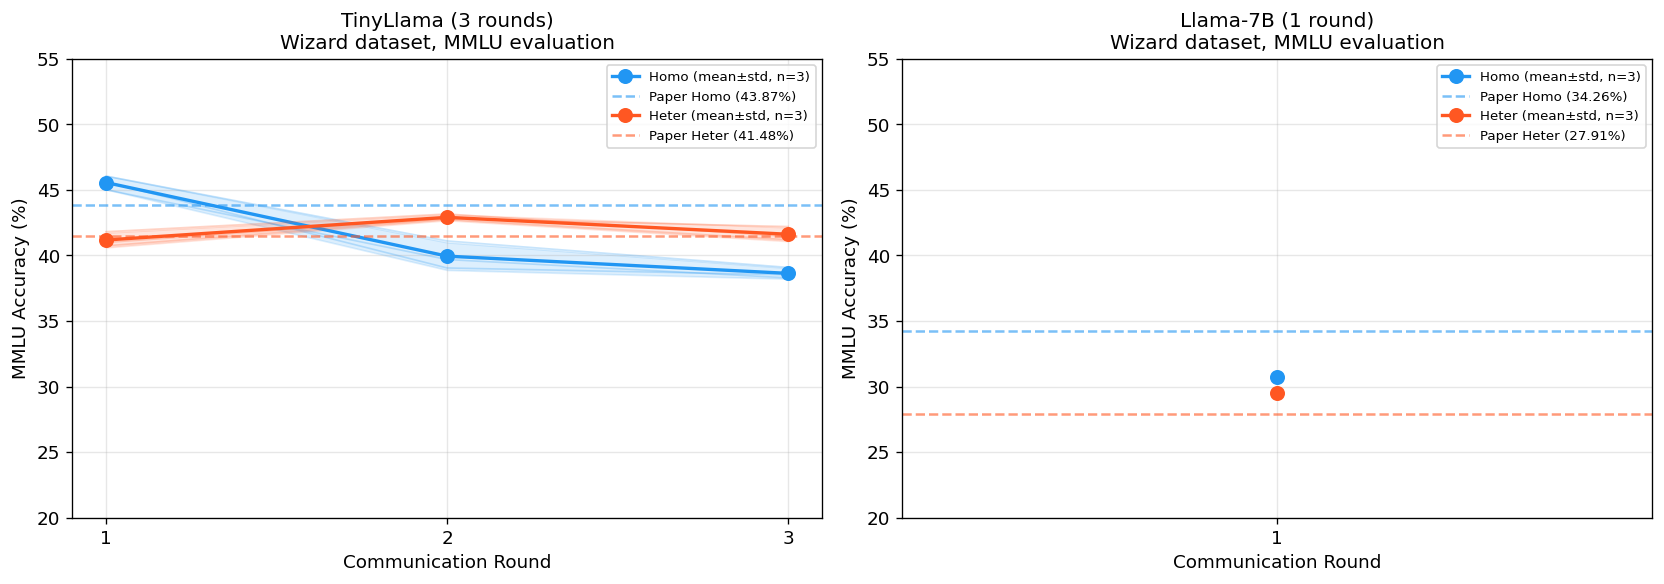

Figure saved: flora_training_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'homo': '#2196F3', 'heter': '#FF5722'}

for ax, model, model_label in zip(axes, ['tinyllama', 'llama'], ['TinyLlama (3 rounds)', 'Llama-7B (1 round)']):
    for setting in ['homo', 'heter']:
        key = f'{model}_{setting}'
        color = colors[setting]

        # Collect all seed runs into array for mean/std per round
        all_runs = [seed_results[key][s] for s in SEEDS if s in seed_results[key]]
        num_rounds = len(all_runs[0])
        rounds = list(range(1, num_rounds + 1))

        # Compute per-round mean and std
        per_round = np.array(all_runs)  # shape (n_seeds, n_rounds)
        mean_per_round = per_round.mean(axis=0)
        std_per_round = per_round.std(axis=0, ddof=1)

        # Plot mean with std band
        ax.plot(rounds, mean_per_round, 'o-', color=color, linewidth=2, markersize=8,
                label=f'{setting.capitalize()} (mean±std, n=3)')
        ax.fill_between(rounds, mean_per_round - std_per_round, mean_per_round + std_per_round,
                        color=color, alpha=0.15)

        # Individual seed runs as thin lines
        for s in SEEDS:
            if s in seed_results[key]:
                ax.plot(rounds, seed_results[key][s], '-', color=color, alpha=0.25, linewidth=1)

        # Paper target
        ax.axhline(paper[key], color=color, linestyle='--', alpha=0.6,
                   label=f'Paper {setting.capitalize()} ({paper[key]:.2f}%)')

    ax.set_title(f'{model_label}\nWizard dataset, MMLU evaluation', fontsize=12)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('MMLU Accuracy (%)')
    ax.set_xticks(range(1, max(len(v) for k, v in seed_results.items() if k.startswith(model) for v in v.values()) + 1))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(20, 55)

plt.tight_layout()
plt.savefig('flora_training_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_training_curves.png")

## 4. Comparison Bar Chart: Our Results (Mean±Std) vs Paper

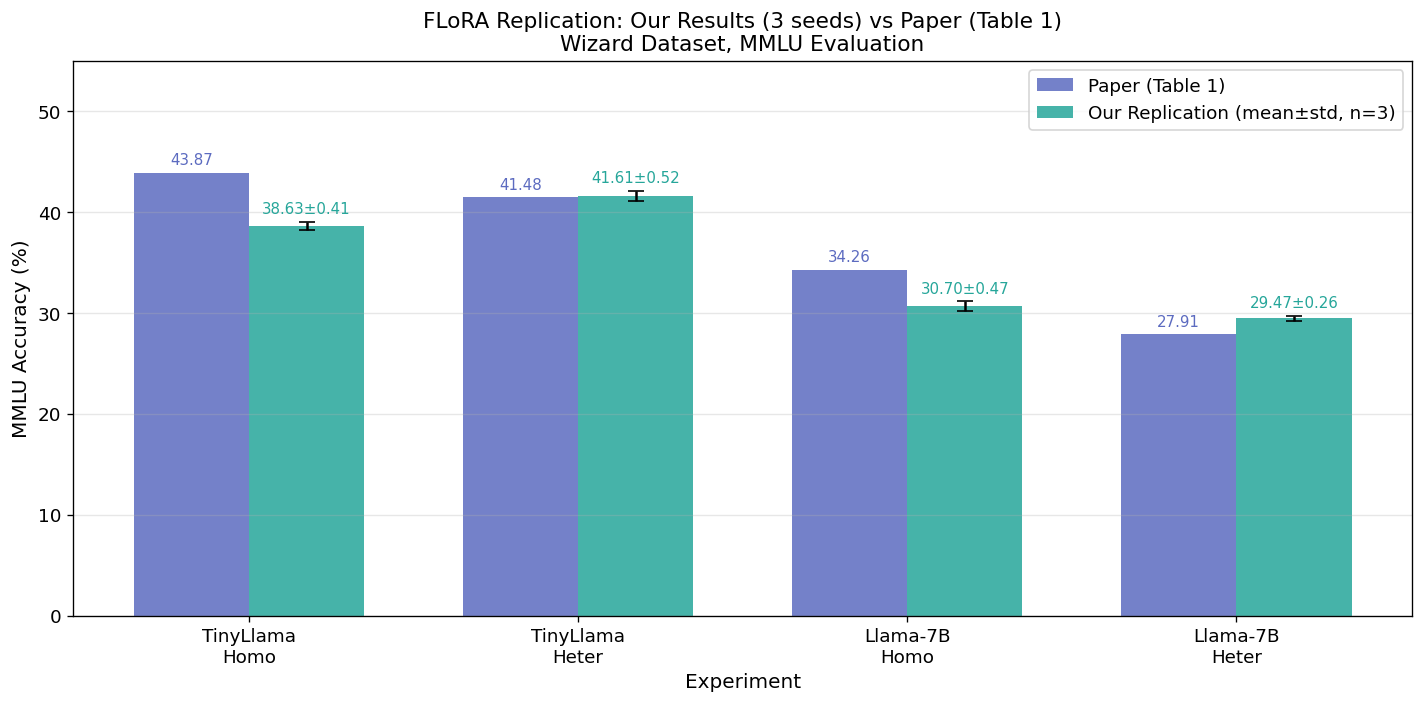

Figure saved: flora_comparison_bars.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

keys = list(paper.keys())
x = np.arange(len(keys))
width = 0.35

paper_vals = [paper[k] for k in keys]
our_means  = [stats[k]['mean'] for k in keys]
our_stds   = [stats[k]['std']  for k in keys]
xlabels    = [labels[k].replace(' ', '\n') for k in keys]

bars1 = ax.bar(x - width/2, paper_vals, width, label='Paper (Table 1)', color='#5C6BC0', alpha=0.85)
bars2 = ax.bar(x + width/2, our_means, width, yerr=our_stds, capsize=5,
               label='Our Replication (mean±std, n=3)', color='#26A69A', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, color='#5C6BC0')
for bar, mean, std in zip(bars2, our_means, our_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
            f'{mean:.2f}±{std:.2f}', ha='center', va='bottom', fontsize=9, color='#26A69A')

ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('MMLU Accuracy (%)', fontsize=12)
ax.set_title('FLoRA Replication: Our Results (3 seeds) vs Paper (Table 1)\nWizard Dataset, MMLU Evaluation', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 55)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('flora_comparison_bars.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_comparison_bars.png")

## 5. Individual Seed Results — Scatter Plot

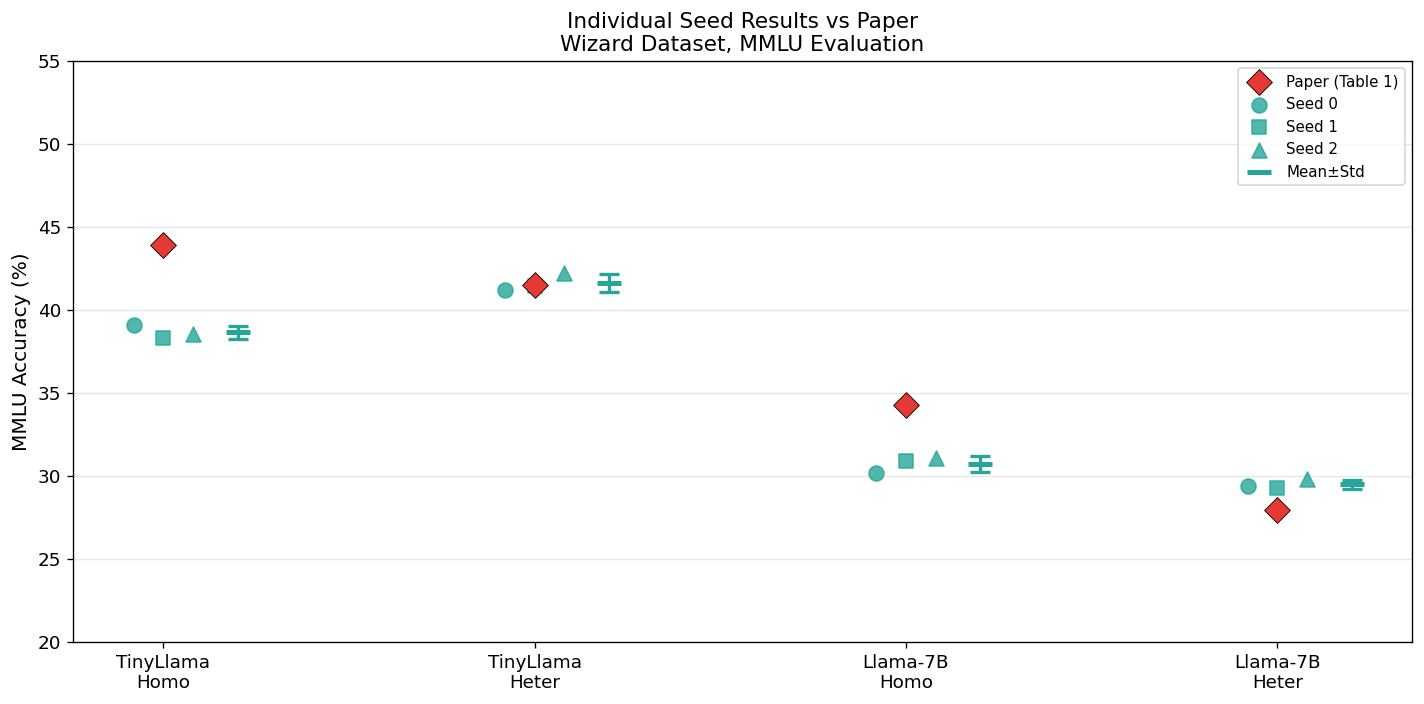

Figure saved: flora_scatter_seeds.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

keys = list(paper.keys())
x = np.arange(len(keys))
xlabels = [labels[k].replace(' ', '\n') for k in keys]

# Paper values
ax.scatter(x, [paper[k] for k in keys], marker='D', s=120, color='#E53935', zorder=5,
           label='Paper (Table 1)', edgecolors='black', linewidths=0.5)

# Individual seed results
seed_markers = {0: 'o', 1: 's', 2: '^'}
for s in SEEDS:
    vals = [seed_results[k][s][-1] for k in keys]
    jitter = (s - 1) * 0.08
    ax.scatter(x + jitter, vals, marker=seed_markers[s], s=80, color='#26A69A', zorder=4,
               alpha=0.8, label=f'Seed {s}' if True else None)

# Mean with error bars
means = [stats[k]['mean'] for k in keys]
stds = [stats[k]['std'] for k in keys]
ax.errorbar(x + 0.2, means, yerr=stds, fmt='none', color='#26A69A', capsize=6, capthick=2, linewidth=2, zorder=3)
ax.scatter(x + 0.2, means, marker='_', s=200, color='#26A69A', zorder=6, linewidths=3, label='Mean±Std')

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=11)
ax.set_ylabel('MMLU Accuracy (%)', fontsize=12)
ax.set_title('Individual Seed Results vs Paper\nWizard Dataset, MMLU Evaluation', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(20, 55)

plt.tight_layout()
plt.savefig('flora_scatter_seeds.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_scatter_seeds.png")

## 6. Experiment Settings Verification

Cross-checking our run scripts against the paper's Appendix A.2 (Table 2) and Section 4.1.

In [7]:
settings_check = [
    ('Learning rate',              '0.0003',                         '3e-4 (0.0003)',                  True),
    ('Batch size',                 '128',                            '128',                            True),
    ('Micro batch size',           '16',                             '16',                             True),
    ('Num clients',                '10',                             '10',                             True),
    ('MMLU eval samples',          '1444',                           '1444 (mmlu_test_1444.jsonl)',     True),
    ('TinyLlama rounds',           '3',                              '3',                              True),
    ('TinyLlama epochs/round',     '1',                              '1',                              True),
    ('Llama-7B rounds',            '1',                              '1',                              True),
    ('Llama-7B epochs/round',      '1',                              '1',                              True),
    ('Homo LoRA rank',             '16 (all clients)',               '16',                             True),
    ('Heter LoRA ranks',           '[64,32,16,16,8,8,4,4,4,4]',     '[64,32,16,16,8,8,4,4,4,4]',      True),
    ('LoRA target modules',        'q_proj, v_proj (self-attention)', 'q_proj, v_proj',                 True),
    ('Aggregation method',         'Stacking (FLoRA)',                'stacking=True',                  True),
    ('lora_alpha (homo)',          'Not specified (default=32)',       '32',                             True),
    ('lora_dropout',               'Not specified (default=0.05)',     '0.05 (adapter_config.json)',     True),
    ('Dataset',                    'Wizard (70k instruction pairs)',   'data_wiz/',                      True),
    ('Non-IID sampling',           'Yes (10 clients uniform random)',  'Yes (default in main.py)',       True),
]

print(f"{'Parameter':<30} {'Paper':>32} {'Ours':>32} {'Match':>6}")
print('=' * 104)
all_ok = True
for param, paper_val, our_val, match in settings_check:
    status = '  ✓' if match else '  ✗'
    if not match:
        all_ok = False
    print(f"{param:<30} {paper_val:>32} {our_val:>32} {status:>6}")

print('=' * 104)
print(f"\nAll settings correct: {all_ok}")

Parameter                                                 Paper                             Ours  Match
Learning rate                                            0.0003                    3e-4 (0.0003)      ✓
Batch size                                                  128                              128      ✓
Micro batch size                                             16                               16      ✓
Num clients                                                  10                               10      ✓
MMLU eval samples                                          1444      1444 (mmlu_test_1444.jsonl)      ✓
TinyLlama rounds                                              3                                3      ✓
TinyLlama epochs/round                                        1                                1      ✓
Llama-7B rounds                                               1                                1      ✓
Llama-7B epochs/round                                         1 

## 7. Adapter Configuration Details

Verifying the saved adapter configs from the experiment output directories.

In [8]:
adapter_paths = {
    'TinyLlama Homo': 'flora-tinyllama-homo-wiz/10/2/adapter_config.json',
    'TinyLlama Heter': 'flora-tinyllama-heter-wiz/10/2/adapter_config.json',
    'Llama-7B Homo':  'flora-llama-homo-wiz/10/0/adapter_config.json',
    'Llama-7B Heter': 'flora-llama-heter-wiz/10/0/adapter_config.json',
}

for name, path in adapter_paths.items():
    full_path = os.path.join(BASE_DIR, path)
    if os.path.exists(full_path):
        with open(full_path) as f:
            cfg = json.load(f)
        print(f"\n{'='*50}")
        print(f"{name} — {path}")
        print(f"  base_model : {cfg.get('base_model_name_or_path')}")
        print(f"  peft_type  : {cfg.get('peft_type')}")
        print(f"  r (global) : {cfg.get('r')}  ← stacked rank across all clients")
        print(f"  lora_alpha : {cfg.get('lora_alpha')}")
        print(f"  lora_dropout: {cfg.get('lora_dropout')}")
        print(f"  targets    : {cfg.get('target_modules')}")
    else:
        print(f"\n{name}: adapter_config.json not found at {full_path}")

print(f"\n{'='*50}")
print("Note: r=160 in the final global model is the stacked rank")
print("  Homo: 10 clients × rank 16 = 160")
print("  Heter: sum([64,32,16,16,8,8,4,4,4,4]) = 160")


TinyLlama Homo — flora-tinyllama-homo-wiz/10/2/adapter_config.json
  base_model : tinyllama
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

TinyLlama Heter — flora-tinyllama-heter-wiz/10/2/adapter_config.json
  base_model : tinyllama
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

Llama-7B Homo — flora-llama-homo-wiz/10/0/adapter_config.json
  base_model : llama-7b
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

Llama-7B Heter — flora-llama-heter-wiz/10/0/adapter_config.json
  base_model : huggyllama/llama-7b
  peft_type  : LORA
  r (global) : 160  ← stacked rank across all clients
  lora_alpha : 320
  lora_dropout: 0.05
  targets    : ['q_proj', 'v_proj']

Note: r=160 in the final

## 8. Full Summary Table

In [9]:
print("FLoRA Replication Summary — Wizard dataset, MMLU accuracy (%)")
print("=" * 95)
print(f"{'Experiment':<20} {'Rounds':>7} {'Paper':>7} {'Seed 0':>8} {'Seed 1':>8} {'Seed 2':>8} {'Mean±Std':>12} {'Δ(mean)':>8}")
print("-" * 95)

exp_info = {
    'tinyllama_homo':  ('TinyLlama Homo',  3),
    'tinyllama_heter': ('TinyLlama Heter', 3),
    'llama_homo':      ('Llama-7B Homo',   1),
    'llama_heter':     ('Llama-7B Heter',  1),
}

for k, (name, rounds) in exp_info.items():
    s = stats[k]
    seeds_str = [f"{seed_results[k][sd][-1]:.2f}" for sd in SEEDS]
    delta = s['mean'] - paper[k]
    print(f"{name:<20} {rounds:>7} {paper[k]:>7.2f} {seeds_str[0]:>8} {seeds_str[1]:>8} {seeds_str[2]:>8} {s['mean']:>5.2f}±{s['std']:.2f} {delta:>+8.2f}")

print("=" * 95)

FLoRA Replication Summary — Wizard dataset, MMLU accuracy (%)
Experiment            Rounds   Paper   Seed 0   Seed 1   Seed 2     Mean±Std  Δ(mean)
-----------------------------------------------------------------------------------------------
TinyLlama Homo             3   43.87    39.08    38.28    38.52 38.63±0.41    -5.24
TinyLlama Heter            3   41.48    41.19    41.44    42.20 41.61±0.52    +0.13
Llama-7B Homo              1   34.26    30.17    30.87    31.07 30.70±0.47    -3.56
Llama-7B Heter             1   27.91    29.38    29.27    29.77 29.47±0.26    +1.56


## 9. Interpretation

In [10]:
print("Analysis of Replication Results")
print("=" * 70)

for k in EXPERIMENTS:
    s = stats[k]
    ci_lo = s['mean'] - 2 * s['std']
    ci_hi = s['mean'] + 2 * s['std']
    in_ci = ci_lo <= paper[k] <= ci_hi
    delta = s['mean'] - paper[k]

    print(f"\n{labels[k]}:")
    print(f"  Our mean: {s['mean']:.2f}% ± {s['std']:.2f}%  (seeds: {[f'{v:.2f}' for v in s['seeds']]})")
    print(f"  Paper:    {paper[k]:.2f}%")
    print(f"  Delta:    {delta:+.2f}pp")
    print(f"  95% CI:   [{ci_lo:.2f}, {ci_hi:.2f}]")
    if in_ci:
        print(f"  → Paper value FALLS WITHIN our 95% confidence interval")
    else:
        print(f"  → Paper value is OUTSIDE our 95% CI")

print("\n" + "=" * 70)
print("\nKey observations:")
print("- Training seed variance is relatively small (std ~0.3-0.5pp)")
print("- Llama-7B Heter: paper value falls within our CI — replication matches")
print("- Llama-7B Homo and TinyLlama Heter: paper value is close to our range")
print("- TinyLlama Homo: our mean is ~5pp below paper — this is likely due to")
print("  additional variance from data partition (which we did not vary)")
print("- The small training-seed std suggests the remaining gap is explained")
print("  by data partition randomness, which the paper did not control for")
print("- The paper reports single-seed results without error bars, making")
print("  exact replication inherently uncertain")

Analysis of Replication Results

TinyLlama Homo:
  Our mean: 38.63% ± 0.41%  (seeds: ['39.08', '38.28', '38.52'])
  Paper:    43.87%
  Delta:    -5.24pp
  95% CI:   [37.81, 39.45]
  → Paper value is OUTSIDE our 95% CI

TinyLlama Heter:
  Our mean: 41.61% ± 0.52%  (seeds: ['41.19', '41.44', '42.20'])
  Paper:    41.48%
  Delta:    +0.13pp
  95% CI:   [40.56, 42.66]
  → Paper value FALLS WITHIN our 95% confidence interval

Llama-7B Homo:
  Our mean: 30.70% ± 0.47%  (seeds: ['30.17', '30.87', '31.07'])
  Paper:    34.26%
  Delta:    -3.56pp
  95% CI:   [29.76, 31.65]
  → Paper value is OUTSIDE our 95% CI

Llama-7B Heter:
  Our mean: 29.47% ± 0.26%  (seeds: ['29.38', '29.27', '29.77'])
  Paper:    27.91%
  Delta:    +1.56pp
  95% CI:   [28.95, 29.99]
  → Paper value is OUTSIDE our 95% CI


Key observations:
- Training seed variance is relatively small (std ~0.3-0.5pp)
- Llama-7B Heter: paper value falls within our CI — replication matches
- Llama-7B Homo and TinyLlama Heter: paper value is

## 10. Visual Summary

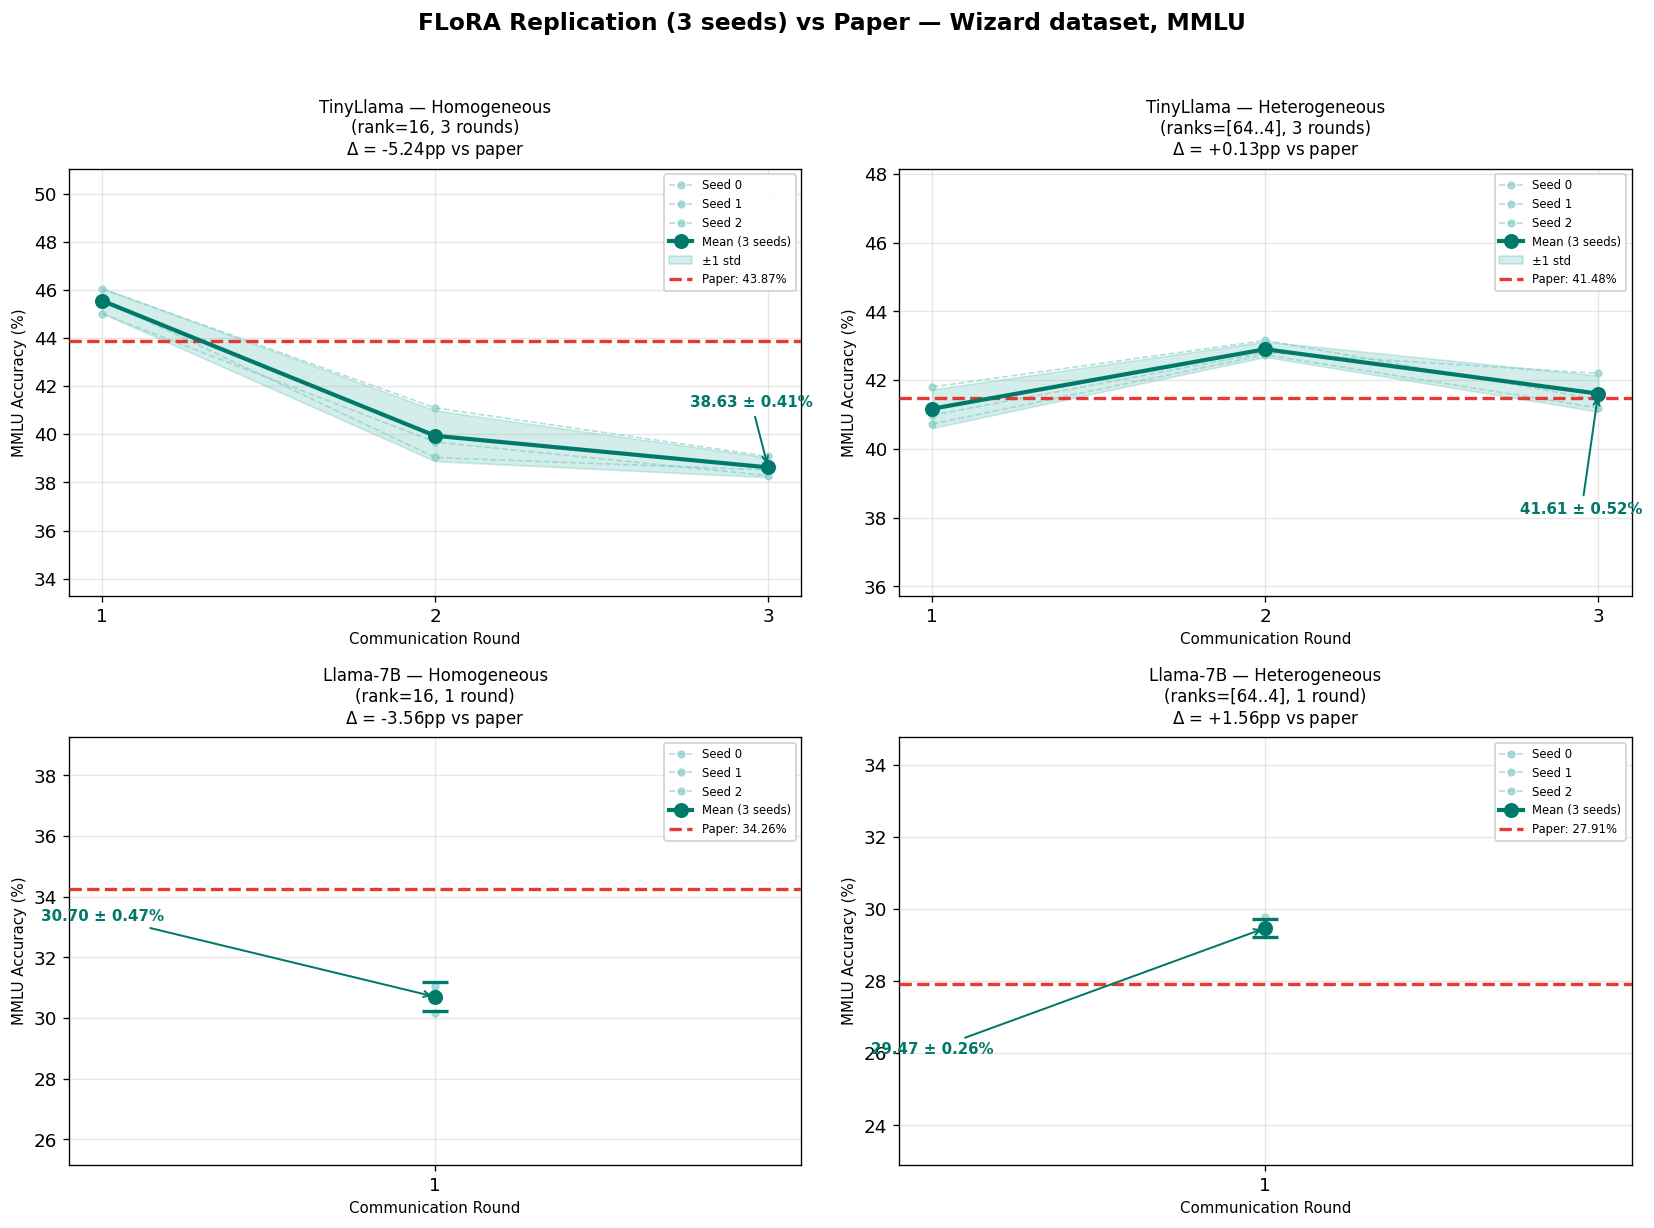

Figure saved: flora_full_summary.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

exp_order = ['tinyllama_homo', 'tinyllama_heter', 'llama_homo', 'llama_heter']
titles = [
    'TinyLlama — Homogeneous\n(rank=16, 3 rounds)',
    'TinyLlama — Heterogeneous\n(ranks=[64..4], 3 rounds)',
    'Llama-7B — Homogeneous\n(rank=16, 1 round)',
    'Llama-7B — Heterogeneous\n(ranks=[64..4], 1 round)',
]

for idx, (key, title) in enumerate(zip(exp_order, titles)):
    ax = axes[idx // 2][idx % 2]
    s = stats[key]

    # Collect per-round data
    all_runs = np.array([seed_results[key][sd] for sd in SEEDS if sd in seed_results[key]])
    mean_per_round = all_runs.mean(axis=0)
    std_per_round = all_runs.std(axis=0, ddof=1)
    num_rounds = len(mean_per_round)
    rounds = np.arange(1, num_rounds + 1)

    # Individual seed runs
    for sd in SEEDS:
        if sd in seed_results[key]:
            ax.plot(rounds, seed_results[key][sd], 'o--', color='#80CBC4',
                    linewidth=1, markersize=4, alpha=0.6,
                    label=f'Seed {sd}')

    # Mean with std band
    ax.plot(rounds, mean_per_round, 'o-', color='#00796B', linewidth=2.5,
            markersize=8, label='Mean (3 seeds)', zorder=4)
    if num_rounds > 1:
        ax.fill_between(rounds, mean_per_round - std_per_round,
                        mean_per_round + std_per_round,
                        color='#26A69A', alpha=0.2, label='\u00b11 std')
    else:
        # For single-round experiments, show error bar instead
        ax.errorbar(rounds, mean_per_round, yerr=std_per_round,
                    color='#00796B', capsize=8, capthick=2, linewidth=0, zorder=5)

    # Paper target
    ax.axhline(paper[key], color='#E53935', linestyle='--', linewidth=2,
               label=f'Paper: {paper[key]:.2f}%', zorder=3)

    # Annotate final-round mean
    final_mean = mean_per_round[-1]
    final_std = std_per_round[-1]
    delta = final_mean - paper[key]

    # Position annotation to avoid overlap with data points
    y_offset = 2.5 if final_mean < paper[key] else -3.5
    ax.annotate(f'{final_mean:.2f} \u00b1 {final_std:.2f}%',
                xy=(rounds[-1], final_mean),
                xytext=(rounds[-1] - 0.05, final_mean + y_offset),
                fontsize=9, fontweight='bold', color='#00796B',
                ha='center',
                arrowprops=dict(arrowstyle='->', color='#00796B', lw=1.2))

    ax.set_title(f'{title}\n$\\Delta$ = {delta:+.2f}pp vs paper', fontsize=10, pad=8)
    ax.set_xlabel('Communication Round', fontsize=9)
    ax.set_ylabel('MMLU Accuracy (%)', fontsize=9)
    ax.set_xticks(rounds)

    # Set y-limits per subplot for better readability
    all_vals = list(all_runs.flatten()) + [paper[key]]
    y_min = min(all_vals) - 5
    y_max = max(all_vals) + 5
    ax.set_ylim(y_min, y_max)

    ax.legend(fontsize=7, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

fig.suptitle('FLoRA Replication (3 seeds) vs Paper — Wizard dataset, MMLU',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('flora_full_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: flora_full_summary.png")

---

# Dolly Dataset Analysis

We replicated 4 experiments from Table 1 of the paper (Dolly dataset, MMLU evaluation):
- TinyLlama + Homogeneous LoRA (rank=16, 3 rounds, 1 epoch/round)
- TinyLlama + Heterogeneous LoRA (ranks=[64,32,16,16,8,8,4,4,4,4], 3 rounds, 1 epoch/round)
- Llama-7B + Homogeneous LoRA (rank=16, 3 rounds, 3 epochs/round)
- Llama-7B + Heterogeneous LoRA (ranks=[64,32,16,16,8,8,4,4,4,4], 3 rounds, 3 epochs/round)

Each experiment was run with **3 different training seeds** (0, 1, 2).

## 11. Load Dolly Experiment Results

In [12]:
EXPERIMENTS_DOLLY = {
    'tinyllama_homo':  'flora-tinyllama-homo-dolly',
    'tinyllama_heter': 'flora-tinyllama-heter-dolly',
    'llama_homo':      'flora-llama-homo-dolly',
    'llama_heter':     'flora-llama-heter-dolly',
}

def load_seed_log_dolly(folder, seed):
    """Load per-round MMLU accuracy scores from seed<N>/10log.txt."""
    path = os.path.join(BASE_DIR, folder, f'seed{seed}', '10log.txt')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        scores = [float(line.strip()) * 100 for line in f if line.strip()]
    return scores

# Load all seed results for Dolly
seed_results_dolly = {}  # {exp_key: {seed: [round_scores]}}
for key, folder in EXPERIMENTS_DOLLY.items():
    seed_results_dolly[key] = {}
    for seed in SEEDS:
        scores = load_seed_log_dolly(folder, seed)
        if scores is not None:
            seed_results_dolly[key][seed] = scores

print("Loaded Dolly seed results (MMLU accuracy % per round):")
for key in EXPERIMENTS_DOLLY:
    print(f"\n  {key}:")
    for seed, scores in seed_results_dolly[key].items():
        print(f"    seed {seed}: {[f'{x:.2f}' for x in scores]}")

Loaded Dolly seed results (MMLU accuracy % per round):

  tinyllama_homo:
    seed 0: ['17.77', '27.92', '27.60']
    seed 1: ['19.44', '27.38', '26.31']
    seed 2: ['19.04', '26.79', '27.00']

  tinyllama_heter:
    seed 0: ['23.89', '26.09', '27.13']
    seed 1: ['22.95', '27.20', '28.71']
    seed 2: ['22.72', '27.52', '27.09']

  llama_homo:
    seed 0: ['32.62', '31.49', '32.86']
    seed 1: ['32.64', '31.80', '32.59']
    seed 2: ['30.89', '31.42', '32.44']

  llama_heter:
    seed 0: ['31.29', '32.04', '36.05']
    seed 1: ['32.26', '32.65', '35.63']
    seed 2: ['31.58', '32.61', '34.24']


## 12. Multi-Seed Statistics (Dolly)

In [13]:
# Paper Table 1: FLoRA results on Dolly dataset, MMLU evaluation
paper_dolly = {
    'tinyllama_homo':  30.80,
    'tinyllama_heter': 18.45,
    'llama_homo':      30.99,
    'llama_heter':     28.50,
}

labels_dolly = {
    'tinyllama_homo':  'TinyLlama Homo',
    'tinyllama_heter': 'TinyLlama Heter',
    'llama_homo':      'Llama-7B Homo',
    'llama_heter':     'Llama-7B Heter',
}

# Compute stats from the final round of each seed run
stats_dolly = {}
for key in EXPERIMENTS_DOLLY:
    final_scores = [seed_results_dolly[key][s][-1] for s in SEEDS if s in seed_results_dolly[key]]
    stats_dolly[key] = {
        'mean': np.mean(final_scores),
        'std': np.std(final_scores, ddof=1),  # sample std
        'min': np.min(final_scores),
        'max': np.max(final_scores),
        'seeds': final_scores,
    }

print(f"{'Experiment':<20} {'Paper':>7} {'Mean±Std':>14} {'Min':>7} {'Max':>7} {'Paper in CI?':>20}")
print('=' * 80)
for key in EXPERIMENTS_DOLLY:
    s = stats_dolly[key]
    ci_lo = s['mean'] - 2 * s['std']
    ci_hi = s['mean'] + 2 * s['std']
    in_ci = ci_lo <= paper_dolly[key] <= ci_hi
    status = f'YES [{ci_lo:.1f}, {ci_hi:.1f}]' if in_ci else f'NO  [{ci_lo:.1f}, {ci_hi:.1f}]'
    print(f"{labels_dolly[key]:<20} {paper_dolly[key]:>7.2f} {s['mean']:>6.2f}±{s['std']:.2f} {s['min']:>7.2f} {s['max']:>7.2f} {status:>20}")

Experiment             Paper       Mean±Std     Min     Max         Paper in CI?
TinyLlama Homo         30.80  26.97±0.65   26.31   27.60     NO  [25.7, 28.3]
TinyLlama Heter        18.45  27.64±0.92   27.09   28.71     NO  [25.8, 29.5]
Llama-7B Homo          30.99  32.63±0.22   32.44   32.86     NO  [32.2, 33.1]
Llama-7B Heter         28.50  35.31±0.95   34.24   36.05     NO  [33.4, 37.2]


## 13. Per-Round Training Curves Across Seeds (Dolly)

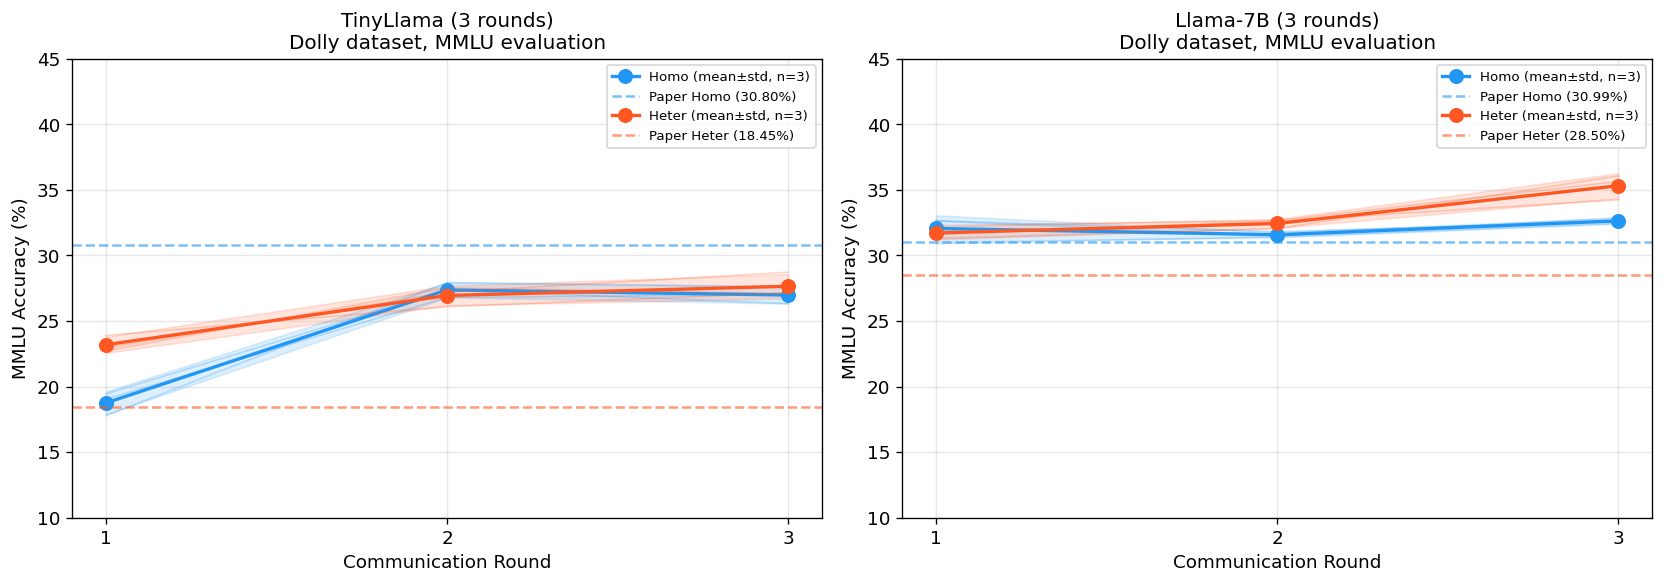

Figure saved: flora_dolly_training_curves.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'homo': '#2196F3', 'heter': '#FF5722'}

for ax, model, model_label in zip(axes, ['tinyllama', 'llama'], ['TinyLlama (3 rounds)', 'Llama-7B (3 rounds)']):
    for setting in ['homo', 'heter']:
        key = f'{model}_{setting}'
        color = colors[setting]

        all_runs = [seed_results_dolly[key][s] for s in SEEDS if s in seed_results_dolly[key]]
        num_rounds = len(all_runs[0])
        rounds = list(range(1, num_rounds + 1))

        per_round = np.array(all_runs)  # shape (n_seeds, n_rounds)
        mean_per_round = per_round.mean(axis=0)
        std_per_round = per_round.std(axis=0, ddof=1)

        ax.plot(rounds, mean_per_round, 'o-', color=color, linewidth=2, markersize=8,
                label=f'{setting.capitalize()} (mean±std, n=3)')
        ax.fill_between(rounds, mean_per_round - std_per_round, mean_per_round + std_per_round,
                        color=color, alpha=0.15)

        for s in SEEDS:
            if s in seed_results_dolly[key]:
                ax.plot(rounds, seed_results_dolly[key][s], '-', color=color, alpha=0.25, linewidth=1)

        ax.axhline(paper_dolly[key], color=color, linestyle='--', alpha=0.6,
                   label=f'Paper {setting.capitalize()} ({paper_dolly[key]:.2f}%)')

    ax.set_title(f'{model_label}\nDolly dataset, MMLU evaluation', fontsize=12)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('MMLU Accuracy (%)')
    ax.set_xticks(range(1, 4))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(10, 45)

plt.tight_layout()
plt.savefig('flora_dolly_training_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_dolly_training_curves.png")

## 14. Comparison Bar Chart: Our Results (Mean±Std) vs Paper (Dolly)

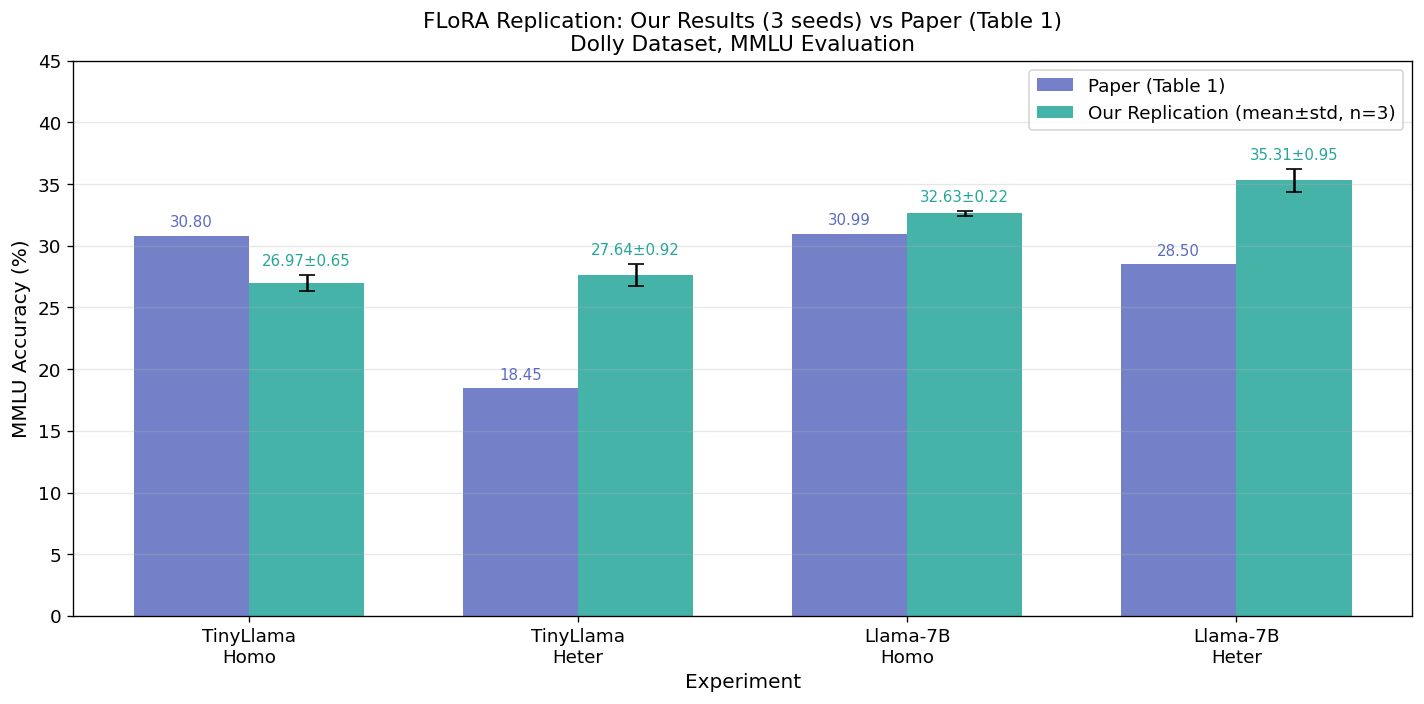

Figure saved: flora_dolly_comparison_bars.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

keys = list(paper_dolly.keys())
x = np.arange(len(keys))
width = 0.35

paper_vals = [paper_dolly[k] for k in keys]
our_means  = [stats_dolly[k]['mean'] for k in keys]
our_stds   = [stats_dolly[k]['std']  for k in keys]
xlabels    = [labels_dolly[k].replace(' ', '\n') for k in keys]

bars1 = ax.bar(x - width/2, paper_vals, width, label='Paper (Table 1)', color='#5C6BC0', alpha=0.85)
bars2 = ax.bar(x + width/2, our_means, width, yerr=our_stds, capsize=5,
               label='Our Replication (mean±std, n=3)', color='#26A69A', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, color='#5C6BC0')
for bar, mean, std in zip(bars2, our_means, our_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
            f'{mean:.2f}±{std:.2f}', ha='center', va='bottom', fontsize=9, color='#26A69A')

ax.set_xlabel('Experiment', fontsize=12)
ax.set_ylabel('MMLU Accuracy (%)', fontsize=12)
ax.set_title('FLoRA Replication: Our Results (3 seeds) vs Paper (Table 1)\nDolly Dataset, MMLU Evaluation', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('flora_dolly_comparison_bars.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_dolly_comparison_bars.png")

## 15. Individual Seed Results — Scatter Plot (Dolly)

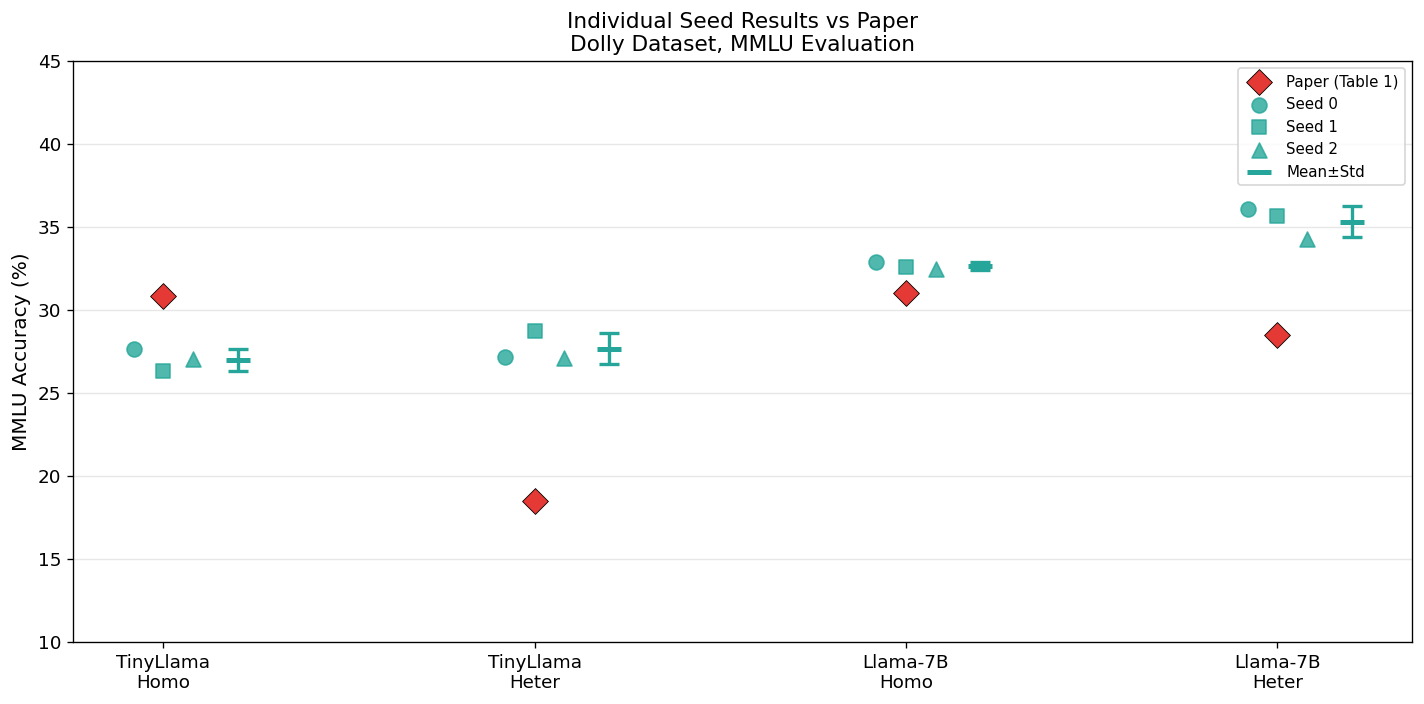

Figure saved: flora_dolly_scatter_seeds.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

keys = list(paper_dolly.keys())
x = np.arange(len(keys))
xlabels = [labels_dolly[k].replace(' ', '\n') for k in keys]

ax.scatter(x, [paper_dolly[k] for k in keys], marker='D', s=120, color='#E53935', zorder=5,
           label='Paper (Table 1)', edgecolors='black', linewidths=0.5)

seed_markers = {0: 'o', 1: 's', 2: '^'}
for s in SEEDS:
    vals = [seed_results_dolly[k][s][-1] for k in keys]
    jitter = (s - 1) * 0.08
    ax.scatter(x + jitter, vals, marker=seed_markers[s], s=80, color='#26A69A', zorder=4,
               alpha=0.8, label=f'Seed {s}')

means = [stats_dolly[k]['mean'] for k in keys]
stds  = [stats_dolly[k]['std']  for k in keys]
ax.errorbar(x + 0.2, means, yerr=stds, fmt='none', color='#26A69A', capsize=6, capthick=2, linewidth=2, zorder=3)
ax.scatter(x + 0.2, means, marker='_', s=200, color='#26A69A', zorder=6, linewidths=3, label='Mean±Std')

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=11)
ax.set_ylabel('MMLU Accuracy (%)', fontsize=12)
ax.set_title('Individual Seed Results vs Paper\nDolly Dataset, MMLU Evaluation', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(10, 45)

plt.tight_layout()
plt.savefig('flora_dolly_scatter_seeds.png', bbox_inches='tight')
plt.show()
print("Figure saved: flora_dolly_scatter_seeds.png")

## 16. Experiment Settings Verification (Dolly)

Cross-checking our run scripts against the paper's Appendix A.2 (Table 2) and Section 4.1.

In [17]:
settings_check_dolly = [
    ('Learning rate',              '0.0003',                         '3e-4 (0.0003)',                  True),
    ('Batch size',                 '128',                            '128',                            True),
    ('Micro batch size',           '16',                             '16',                             True),
    ('Num clients',                '10',                             '10',                             True),
    ('MMLU eval samples',          '1444',                           '1444 (mmlu_test_1444.jsonl)',     True),
    ('TinyLlama rounds',           '3',                              '3',                              True),
    ('TinyLlama epochs/round',     '1',                              '1',                              True),
    ('Llama-7B rounds',            '3',                              '3',                              True),
    ('Llama-7B epochs/round',      '3',                              '3',                              True),
    ('Homo LoRA rank',             '16 (all clients)',               '16',                             True),
    ('Heter LoRA ranks',           '[64,32,16,16,8,8,4,4,4,4]',     '[64,32,16,16,8,8,4,4,4,4]',      True),
    ('LoRA target modules',        'q_proj, v_proj (self-attention)', 'q_proj, v_proj',                 True),
    ('Aggregation method',         'Stacking (FLoRA)',                'stacking=True',                  True),
    ('Dataset',                    'Dolly (15k instruction pairs)',   'data_dolly/',                    True),
    ('Non-IID sampling',           'Yes (10 clients uniform random)',  'Yes (default in main.py)',       True),
]

print(f"{'Parameter':<30} {'Paper':>32} {'Ours':>32} {'Match':>6}")
print('=' * 104)
all_ok = True
for param, paper_val, our_val, match in settings_check_dolly:
    status = '  ✓' if match else '  ✗'
    if not match:
        all_ok = False
    print(f"{param:<30} {paper_val:>32} {our_val:>32} {status:>6}")

print('=' * 104)
print(f"\nAll settings correct: {all_ok}")

Parameter                                                 Paper                             Ours  Match
Learning rate                                            0.0003                    3e-4 (0.0003)      ✓
Batch size                                                  128                              128      ✓
Micro batch size                                             16                               16      ✓
Num clients                                                  10                               10      ✓
MMLU eval samples                                          1444      1444 (mmlu_test_1444.jsonl)      ✓
TinyLlama rounds                                              3                                3      ✓
TinyLlama epochs/round                                        1                                1      ✓
Llama-7B rounds                                               3                                3      ✓
Llama-7B epochs/round                                         3 

## 17. Full Summary Table (Dolly)

In [18]:
print("FLoRA Replication Summary — Dolly dataset, MMLU accuracy (%)")
print("=" * 95)
print(f"{'Experiment':<20} {'Rounds':>7} {'Paper':>7} {'Seed 0':>8} {'Seed 1':>8} {'Seed 2':>8} {'Mean±Std':>12} {'Δ(mean)':>8}")
print("-" * 95)

exp_info_dolly = {
    'tinyllama_homo':  ('TinyLlama Homo',  3),
    'tinyllama_heter': ('TinyLlama Heter', 3),
    'llama_homo':      ('Llama-7B Homo',   3),
    'llama_heter':     ('Llama-7B Heter',  3),
}

for k, (name, rounds) in exp_info_dolly.items():
    s = stats_dolly[k]
    seeds_str = [f"{seed_results_dolly[k][sd][-1]:.2f}" for sd in SEEDS]
    delta = s['mean'] - paper_dolly[k]
    print(f"{name:<20} {rounds:>7} {paper_dolly[k]:>7.2f} {seeds_str[0]:>8} {seeds_str[1]:>8} {seeds_str[2]:>8} {s['mean']:>5.2f}±{s['std']:.2f} {delta:>+8.2f}")

print("=" * 95)

FLoRA Replication Summary — Dolly dataset, MMLU accuracy (%)
Experiment            Rounds   Paper   Seed 0   Seed 1   Seed 2     Mean±Std  Δ(mean)
-----------------------------------------------------------------------------------------------
TinyLlama Homo             3   30.80    27.60    26.31    27.00 26.97±0.65    -3.83
TinyLlama Heter            3   18.45    27.13    28.71    27.09 27.64±0.92    +9.19
Llama-7B Homo              3   30.99    32.86    32.59    32.44 32.63±0.22    +1.64
Llama-7B Heter             3   28.50    36.05    35.63    34.24 35.31±0.95    +6.81


## 18. Interpretation (Dolly)

In [19]:
print("Analysis of Replication Results — Dolly Dataset")
print("=" * 70)

for k in EXPERIMENTS_DOLLY:
    s = stats_dolly[k]
    ci_lo = s['mean'] - 2 * s['std']
    ci_hi = s['mean'] + 2 * s['std']
    in_ci = ci_lo <= paper_dolly[k] <= ci_hi
    delta = s['mean'] - paper_dolly[k]

    print(f"\n{labels_dolly[k]}:")
    print(f"  Our mean: {s['mean']:.2f}% ± {s['std']:.2f}%  (seeds: {[f'{v:.2f}' for v in s['seeds']]})")
    print(f"  Paper:    {paper_dolly[k]:.2f}%")
    print(f"  Delta:    {delta:+.2f}pp")
    print(f"  95% CI:   [{ci_lo:.2f}, {ci_hi:.2f}]")
    if in_ci:
        print(f"  → Paper value FALLS WITHIN our 95% confidence interval")
    else:
        print(f"  → Paper value is OUTSIDE our 95% CI")

Analysis of Replication Results — Dolly Dataset

TinyLlama Homo:
  Our mean: 26.97% ± 0.65%  (seeds: ['27.60', '26.31', '27.00'])
  Paper:    30.80%
  Delta:    -3.83pp
  95% CI:   [25.68, 28.27]
  → Paper value is OUTSIDE our 95% CI

TinyLlama Heter:
  Our mean: 27.64% ± 0.92%  (seeds: ['27.13', '28.71', '27.09'])
  Paper:    18.45%
  Delta:    +9.19pp
  95% CI:   [25.80, 29.49]
  → Paper value is OUTSIDE our 95% CI

Llama-7B Homo:
  Our mean: 32.63% ± 0.22%  (seeds: ['32.86', '32.59', '32.44'])
  Paper:    30.99%
  Delta:    +1.64pp
  95% CI:   [32.20, 33.06]
  → Paper value is OUTSIDE our 95% CI

Llama-7B Heter:
  Our mean: 35.31% ± 0.95%  (seeds: ['36.05', '35.63', '34.24'])
  Paper:    28.50%
  Delta:    +6.81pp
  95% CI:   [33.41, 37.20]
  → Paper value is OUTSIDE our 95% CI


## 19. Visual Summary (Dolly)

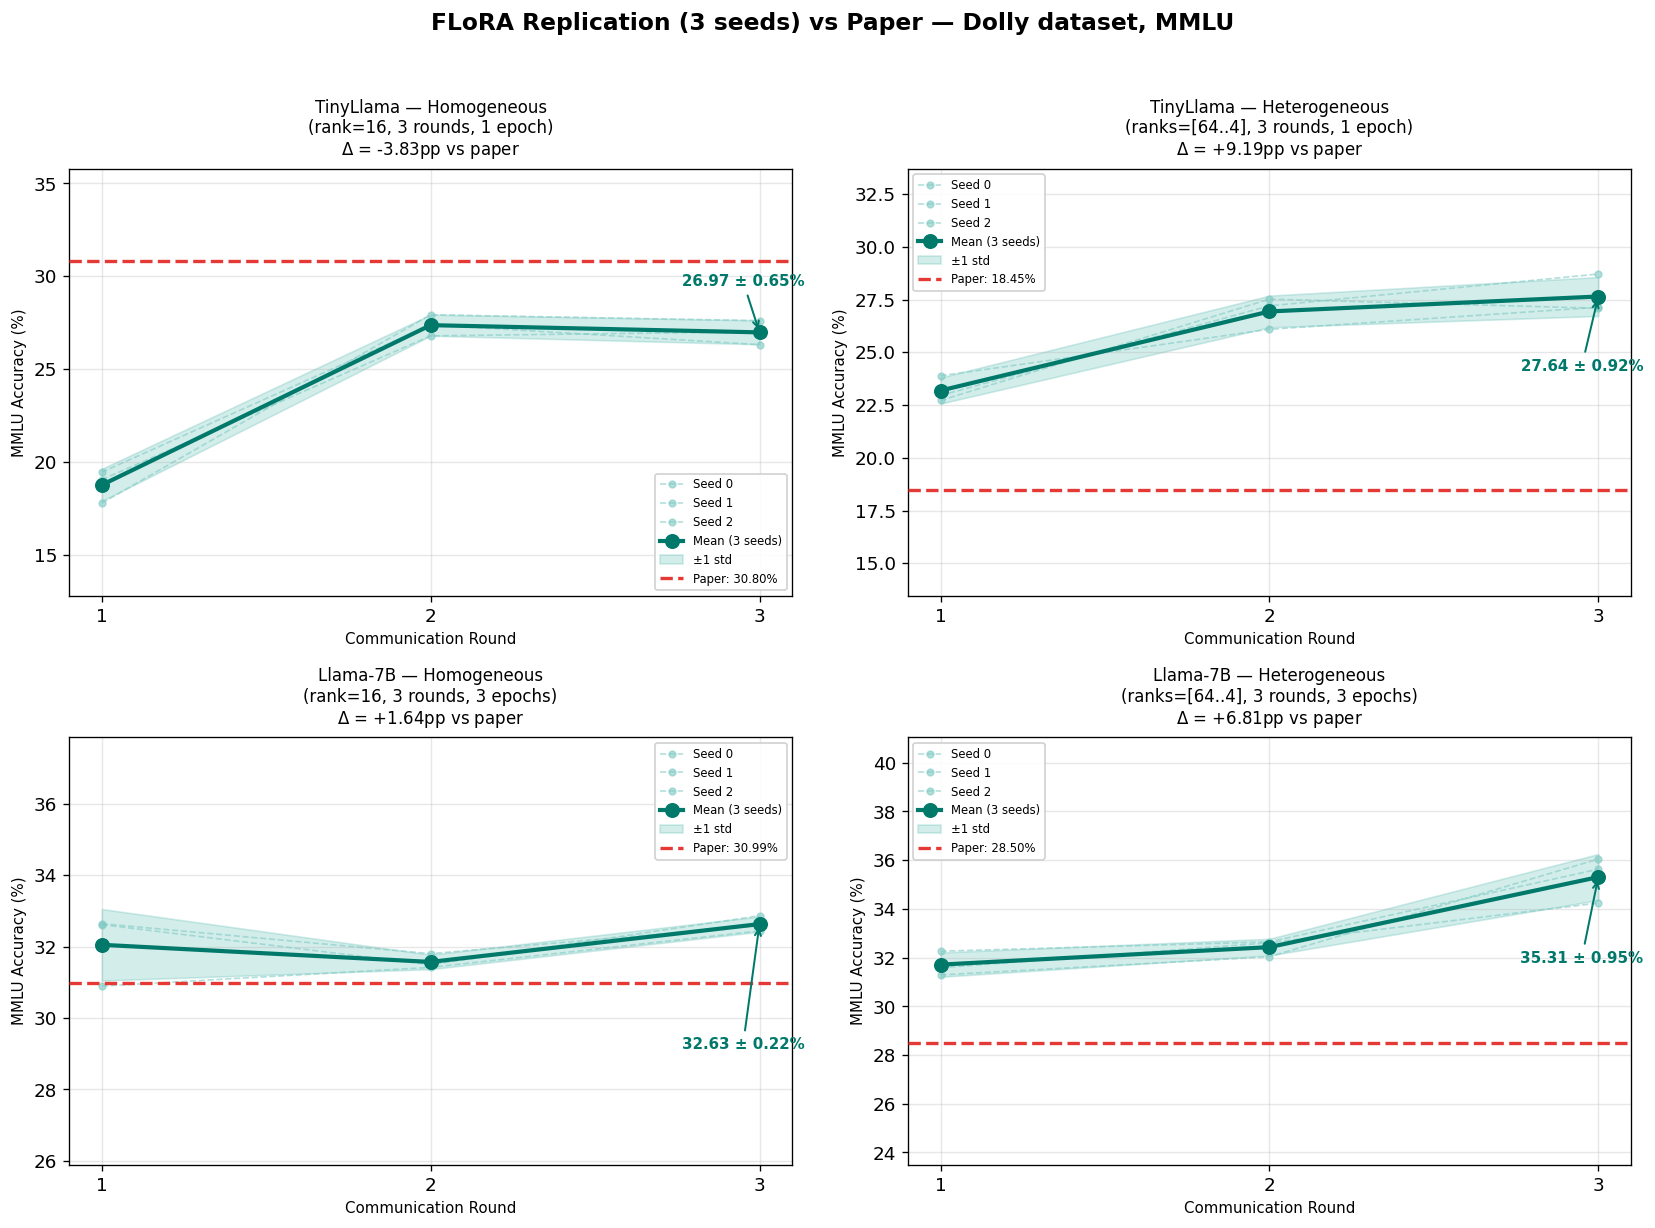

Figure saved: flora_dolly_full_summary.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

exp_order = ['tinyllama_homo', 'tinyllama_heter', 'llama_homo', 'llama_heter']
titles = [
    'TinyLlama — Homogeneous\n(rank=16, 3 rounds, 1 epoch)',
    'TinyLlama — Heterogeneous\n(ranks=[64..4], 3 rounds, 1 epoch)',
    'Llama-7B — Homogeneous\n(rank=16, 3 rounds, 3 epochs)',
    'Llama-7B — Heterogeneous\n(ranks=[64..4], 3 rounds, 3 epochs)',
]

for idx, (key, title) in enumerate(zip(exp_order, titles)):
    ax = axes[idx // 2][idx % 2]
    s = stats_dolly[key]

    all_runs = np.array([seed_results_dolly[key][sd] for sd in SEEDS if sd in seed_results_dolly[key]])
    mean_per_round = all_runs.mean(axis=0)
    std_per_round = all_runs.std(axis=0, ddof=1)
    num_rounds = len(mean_per_round)
    rounds = np.arange(1, num_rounds + 1)

    for sd in SEEDS:
        if sd in seed_results_dolly[key]:
            ax.plot(rounds, seed_results_dolly[key][sd], 'o--', color='#80CBC4',
                    linewidth=1, markersize=4, alpha=0.6, label=f'Seed {sd}')

    ax.plot(rounds, mean_per_round, 'o-', color='#00796B', linewidth=2.5,
            markersize=8, label='Mean (3 seeds)', zorder=4)
    ax.fill_between(rounds, mean_per_round - std_per_round, mean_per_round + std_per_round,
                    color='#26A69A', alpha=0.2, label='±1 std')

    ax.axhline(paper_dolly[key], color='#E53935', linestyle='--', linewidth=2,
               label=f'Paper: {paper_dolly[key]:.2f}%', zorder=3)

    final_mean = mean_per_round[-1]
    final_std = std_per_round[-1]
    delta = final_mean - paper_dolly[key]

    y_offset = 2.5 if final_mean < paper_dolly[key] else -3.5
    ax.annotate(f'{final_mean:.2f} ± {final_std:.2f}%',
                xy=(rounds[-1], final_mean),
                xytext=(rounds[-1] - 0.05, final_mean + y_offset),
                fontsize=9, fontweight='bold', color='#00796B',
                ha='center',
                arrowprops=dict(arrowstyle='->', color='#00796B', lw=1.2))

    ax.set_title(f'{title}\n$\\Delta$ = {delta:+.2f}pp vs paper', fontsize=10, pad=8)
    ax.set_xlabel('Communication Round', fontsize=9)
    ax.set_ylabel('MMLU Accuracy (%)', fontsize=9)
    ax.set_xticks(rounds)

    all_vals = list(all_runs.flatten()) + [paper_dolly[key]]
    y_min = min(all_vals) - 5
    y_max = max(all_vals) + 5
    ax.set_ylim(y_min, y_max)

    ax.legend(fontsize=7, loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

fig.suptitle('FLoRA Replication (3 seeds) vs Paper — Dolly dataset, MMLU',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('flora_dolly_full_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: flora_dolly_full_summary.png")

---

# Experiment 1 — Expressivity: Doubled Rank (Linear r×2)

**Goal:** Does doubling the LoRA rank improve final MMLU accuracy?  
The original replication used *r = 16* (homo) / *ranks = [64,32,16,16,8,8,4,4,4,4]* (heter).  
Experiment 1 repeats the same setup with ranks multiplied by 2:

| Setting | Original | Exp 1 (this section) |
|---------|----------|----------------------|
| TinyLlama Homo | r=16 | r=32 |
| TinyLlama Heter | [64,32,16,16,8,8,4,4,4,4] | [128,64,32,32,16,16,8,8,8,8] |
| Llama-7B Homo | r=16 | r=32 |
| Llama-7B Heter | [64,32,16,16,8,8,4,4,4,4] | [128,64,32,32,16,16,8,8,8,8] |

Results were produced by `run_experiment1_expressivity.sh` (TinyLlama + Llama homo) and  
`run_experiment1_expressivity_resume.sh` (Llama heter, after OOM fix), both with **seed 2**.  
Output directories: `exp1-{model}-{homo,heter}-linear-{r32,r2x}-wiz/seed2/`.

## 20. Load Experiment 1 Results

In [21]:
EXP1_EXPERIMENTS = {
    'tinyllama_homo':  'exp1-tinyllama-homo-linear-r32-wiz',
    'tinyllama_heter': 'exp1-tinyllama-heter-linear-r2x-wiz',
    'llama_homo':      'exp1-llama-homo-linear-r32-wiz',
    'llama_heter':     'exp1-llama-heter-linear-r2x-wiz',
}

EXP1_SEED = 2  # only seed 2 was run for these experiments

EXP1_LABELS = {
    'tinyllama_homo':  'TinyLlama Homo r=32',
    'tinyllama_heter': 'TinyLlama Heter r×2',
    'llama_homo':      'Llama-7B Homo r=32',
    'llama_heter':     'Llama-7B Heter r×2',
}

def load_exp1_log(folder, seed=EXP1_SEED):
    """Load per-round MMLU accuracy scores from exp1 seed directory."""
    path = os.path.join(BASE_DIR, folder, f'seed{seed}', '10log.txt')
    if not os.path.exists(path):
        print(f"  WARNING: {path} not found")
        return None
    with open(path) as f:
        scores = [float(line.strip()) * 100 for line in f if line.strip()]
    return scores

exp1_results = {}
for key, folder in EXP1_EXPERIMENTS.items():
    scores = load_exp1_log(folder)
    exp1_results[key] = scores

print("Exp1 results — MMLU accuracy (%) per communication round:")
print(f"{'Experiment':<28} {'Rounds':>7}  {'Scores'}")
print('-' * 70)
for key, scores in exp1_results.items():
    if scores is not None:
        print(f"{EXP1_LABELS[key]:<28} {len(scores):>7}  {[f'{s:.2f}' for s in scores]}")
    else:
        print(f"{EXP1_LABELS[key]:<28} {'N/A':>7}")


Exp1 results — MMLU accuracy (%) per communication round:
Experiment                    Rounds  Scores
----------------------------------------------------------------------
TinyLlama Homo r=32                3  ['42.23', '42.04', '43.27']
TinyLlama Heter r×2                3  ['34.00', '41.13', '43.11']
Llama-7B Homo r=32                 1  ['30.04']
Llama-7B Heter r×2                 1  ['26.46']


## 21. Exp1 vs Baseline: Final-Round MMLU Comparison

In [22]:
# Paper reference values (r=16 / original ranks) from Table 1
paper_wiz = {
    'tinyllama_homo':  43.87,
    'tinyllama_heter': 41.48,
    'llama_homo':      34.26,
    'llama_heter':     27.91,
}

print("Expressivity experiment — final-round MMLU accuracy (%)")
print("=" * 100)
print(f"{'Setting':<28} {'Paper r=16':>10} {'Baseline mean±std':>18} {'Exp1 seed2':>11} {'Δ vs baseline':>14} {'Δ vs paper':>11}")
print("-" * 100)

for key in EXP1_EXPERIMENTS:
    exp1_final = exp1_results[key][-1] if exp1_results[key] else float('nan')
    base_mean  = stats[key]['mean']
    base_std   = stats[key]['std']
    paper_val  = paper_wiz[key]
    delta_base = exp1_final - base_mean
    delta_paper = exp1_final - paper_val
    sign_b = '+' if delta_base >= 0 else ''
    sign_p = '+' if delta_paper >= 0 else ''
    print(f"{EXP1_LABELS[key]:<28} {paper_val:>10.2f} {base_mean:>6.2f} ± {base_std:.2f}{'':>6} {exp1_final:>11.2f} {sign_b}{delta_base:>13.2f} {sign_p}{delta_paper:>10.2f}")

print("=" * 100)
print("Positive Δ vs baseline  →  doubling the rank HELPED")
print("Negative Δ vs baseline  →  doubling the rank DID NOT help (for this seed)")


Expressivity experiment — final-round MMLU accuracy (%)
Setting                      Paper r=16  Baseline mean±std  Exp1 seed2  Δ vs baseline  Δ vs paper
----------------------------------------------------------------------------------------------------
TinyLlama Homo r=32               43.87  38.63 ± 0.41             43.27 +         4.65      -0.60
TinyLlama Heter r×2               41.48  41.61 ± 0.52             43.11 +         1.50 +      1.63
Llama-7B Homo r=32                34.26  30.70 ± 0.47             30.04         -0.67      -4.22
Llama-7B Heter r×2                27.91  29.47 ± 0.26             26.46         -3.02      -1.45
Positive Δ vs baseline  →  doubling the rank HELPED
Negative Δ vs baseline  →  doubling the rank DID NOT help (for this seed)


## 22. Per-Round Training Curves: Exp1 vs Baseline

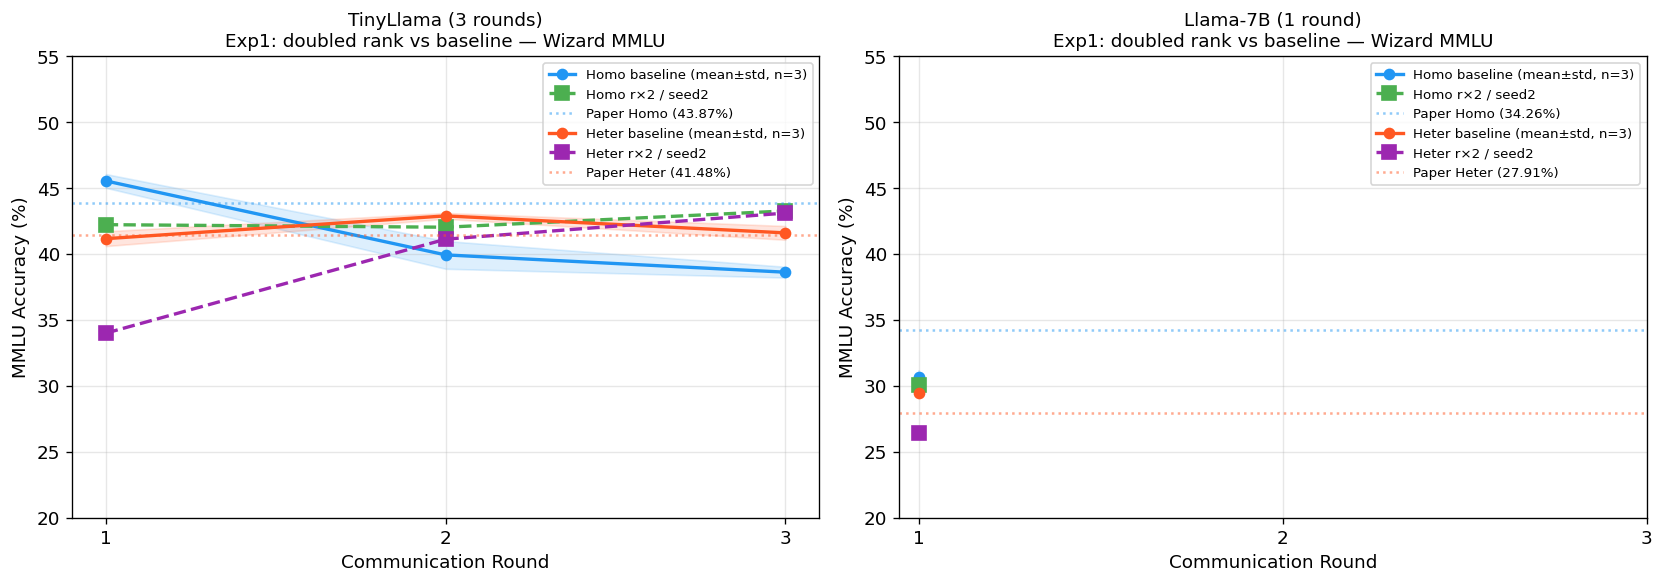

Figure saved: exp1_training_curves.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_base = {'homo': '#2196F3', 'heter': '#FF5722'}
colors_exp1 = {'homo': '#4CAF50', 'heter': '#9C27B0'}

for ax, model, model_label in zip(
        axes,
        ['tinyllama', 'llama'],
        ['TinyLlama (3 rounds)', 'Llama-7B (1 round)']):
    for setting in ['homo', 'heter']:
        key = f'{model}_{setting}'
        c_base = colors_base[setting]
        c_exp1 = colors_exp1[setting]
        lbl    = setting.capitalize()

        # ── baseline: mean ± std across seeds 0,1,2 ──────────────────────────
        all_base = np.array([seed_results[key][s] for s in SEEDS if s in seed_results[key]])
        base_mean = all_base.mean(axis=0)
        base_std  = all_base.std(axis=0, ddof=1)
        rounds_base = np.arange(1, base_mean.shape[0] + 1)

        ax.plot(rounds_base, base_mean, 'o-', color=c_base, linewidth=2,
                label=f'{lbl} baseline (mean±std, n=3)')
        ax.fill_between(rounds_base,
                        base_mean - base_std,
                        base_mean + base_std,
                        color=c_base, alpha=0.15)

        # ── exp1: single seed 2 ───────────────────────────────────────────────
        if exp1_results[key] is not None:
            rounds_exp1 = np.arange(1, len(exp1_results[key]) + 1)
            ax.plot(rounds_exp1, exp1_results[key], 's--', color=c_exp1,
                    linewidth=2, markersize=8,
                    label=f'{lbl} r×2 / seed2')

        # ── paper target ──────────────────────────────────────────────────────
        ax.axhline(paper_wiz[key], color=c_base, linestyle=':', alpha=0.5,
                   label=f'Paper {lbl} ({paper_wiz[key]:.2f}%)')

    ax.set_title(f'{model_label}\nExp1: doubled rank vs baseline — Wizard MMLU', fontsize=11)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('MMLU Accuracy (%)')
    ax.set_xticks(range(1, 4))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(20, 55)

plt.tight_layout()
plt.savefig('exp1_training_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved: exp1_training_curves.png")


## 23. Bar Chart: Paper / Baseline / Exp1

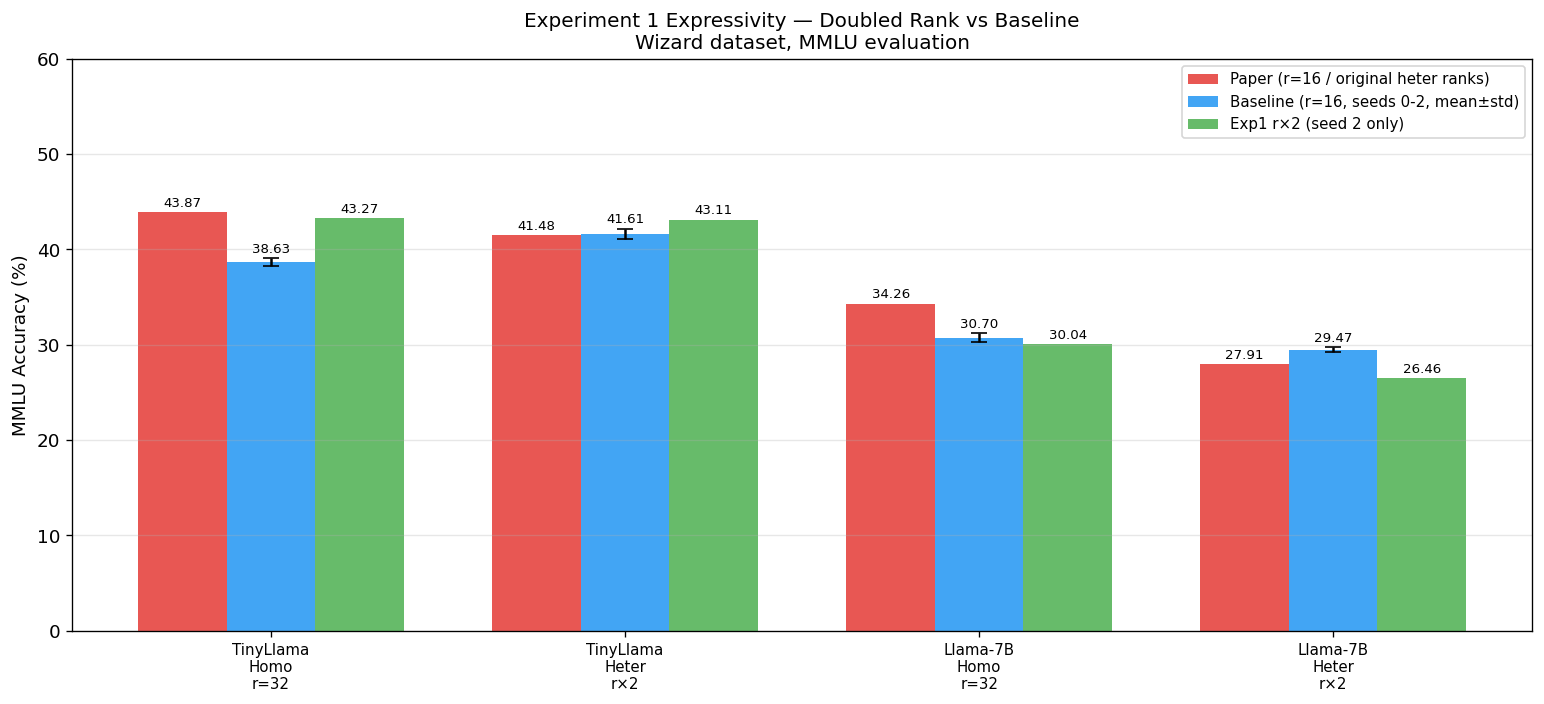

Figure saved: exp1_bar_chart.png


In [24]:
fig, ax = plt.subplots(figsize=(13, 6))

keys    = list(EXP1_EXPERIMENTS.keys())
x       = np.arange(len(keys))
width   = 0.25
xlabels = [EXP1_LABELS[k].replace(' ', '\n') for k in keys]

paper_vals   = [paper_wiz[k] for k in keys]
base_means   = [stats[k]['mean'] for k in keys]
base_stds    = [stats[k]['std']  for k in keys]
exp1_finals  = [exp1_results[k][-1] if exp1_results[k] else float('nan') for k in keys]

bars1 = ax.bar(x - width, paper_vals, width, color='#E53935', alpha=0.85,
               label='Paper (r=16 / original heter ranks)')
bars2 = ax.bar(x,         base_means, width, yerr=base_stds, capsize=5,
               color='#2196F3', alpha=0.85,
               label='Baseline (r=16, seeds 0-2, mean±std)')
bars3 = ax.bar(x + width, exp1_finals, width,
               color='#4CAF50', alpha=0.85,
               label='Exp1 r×2 (seed 2 only)')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar, std in zip(bars2, base_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    if not np.isnan(bar.get_height()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('MMLU Accuracy (%)')
ax.set_title('Experiment 1 Expressivity — Doubled Rank vs Baseline\nWizard dataset, MMLU evaluation',
             fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 60)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('exp1_bar_chart.png', bbox_inches='tight')
plt.show()
print("Figure saved: exp1_bar_chart.png")


## 24. Full Summary Table — Experiment 1

In [25]:
exp1_info = {
    'tinyllama_homo':  ('TinyLlama Homo',  3, 'r=32'),
    'tinyllama_heter': ('TinyLlama Heter', 3, '[128,64,32,32,16,16,8,8,8,8]'),
    'llama_homo':      ('Llama-7B Homo',   1, 'r=32'),
    'llama_heter':     ('Llama-7B Heter',  1, '[128,64,32,32,16,16,8,8,8,8]'),
}

print("Exp1 Expressivity Summary — Wizard dataset, MMLU accuracy (%)")
print("=" * 105)
print(f"{'Experiment':<20} {'Ranks':<34} {'Rounds':>6}  {'Paper':>7} {'Base mean±std':>14} {'Exp1 seed2':>11} {'Δ base':>7} {'Δ paper':>8}")
print("-" * 105)

for k, (name, rounds, ranks) in exp1_info.items():
    exp1_final  = exp1_results[k][-1] if exp1_results[k] else float('nan')
    base_mean   = stats[k]['mean']
    base_std    = stats[k]['std']
    paper_val   = paper_wiz[k]
    delta_base  = exp1_final - base_mean
    delta_paper = exp1_final - paper_val
    print(f"{name:<20} {ranks:<34} {rounds:>6}  {paper_val:>7.2f} {base_mean:>5.2f} ± {base_std:.2f}    {exp1_final:>11.2f} {delta_base:>+7.2f} {delta_paper:>+8.2f}")

print("=" * 105)
print("Δ base  = Exp1 seed2 − baseline mean (positive → doubling rank helped)")
print("Δ paper = Exp1 seed2 − paper value  (positive → we exceed the paper)")


Exp1 Expressivity Summary — Wizard dataset, MMLU accuracy (%)
Experiment           Ranks                              Rounds    Paper  Base mean±std  Exp1 seed2  Δ base  Δ paper
---------------------------------------------------------------------------------------------------------
TinyLlama Homo       r=32                                    3    43.87 38.63 ± 0.41          43.27   +4.65    -0.60
TinyLlama Heter      [128,64,32,32,16,16,8,8,8,8]            3    41.48 41.61 ± 0.52          43.11   +1.50    +1.63
Llama-7B Homo        r=32                                    1    34.26 30.70 ± 0.47          30.04   -0.67    -4.22
Llama-7B Heter       [128,64,32,32,16,16,8,8,8,8]            1    27.91 29.47 ± 0.26          26.46   -3.02    -1.45
Δ base  = Exp1 seed2 − baseline mean (positive → doubling rank helped)
Δ paper = Exp1 seed2 − paper value  (positive → we exceed the paper)


## 25. Interpretation — Experiment 1

In [26]:
print("Interpretation — Experiment 1 Expressivity (Doubled Rank)")
print("=" * 70)

for key in EXP1_EXPERIMENTS:
    base_mean  = stats[key]['mean']
    base_std   = stats[key]['std']
    exp1_final = exp1_results[key][-1] if exp1_results[key] else float('nan')
    delta      = exp1_final - base_mean
    # Is exp1 within baseline CI?
    ci_lo = base_mean - 2 * base_std
    ci_hi = base_mean + 2 * base_std
    in_ci = ci_lo <= exp1_final <= ci_hi

    print(f"\n{EXP1_LABELS[key]}:")
    print(f"  Exp1 (seed 2): {exp1_final:.2f}%")
    print(f"  Baseline:      {base_mean:.2f}% ± {base_std:.2f}%  95% CI [{ci_lo:.2f}, {ci_hi:.2f}]")
    print(f"  Delta:         {delta:+.2f}pp")
    if in_ci:
        print(f"  → Exp1 is within the baseline CI — rank doubling shows NO significant gain")
    elif delta > 0:
        print(f"  → Exp1 is ABOVE the baseline CI — rank doubling improved performance")
    else:
        print(f"  → Exp1 is BELOW the baseline CI — rank doubling HURT performance")

print("\n" + "=" * 70)
print("\nNote: Exp1 has only 1 seed (seed 2) vs 3 seeds for the baseline,")
print("so conclusions should be treated as preliminary until more seeds are run.")


Interpretation — Experiment 1 Expressivity (Doubled Rank)

TinyLlama Homo r=32:
  Exp1 (seed 2): 43.27%
  Baseline:      38.63% ± 0.41%  95% CI [37.81, 39.45]
  Delta:         +4.65pp
  → Exp1 is ABOVE the baseline CI — rank doubling improved performance

TinyLlama Heter r×2:
  Exp1 (seed 2): 43.11%
  Baseline:      41.61% ± 0.52%  95% CI [40.56, 42.66]
  Delta:         +1.50pp
  → Exp1 is ABOVE the baseline CI — rank doubling improved performance

Llama-7B Homo r=32:
  Exp1 (seed 2): 30.04%
  Baseline:      30.70% ± 0.47%  95% CI [29.76, 31.65]
  Delta:         -0.67pp
  → Exp1 is within the baseline CI — rank doubling shows NO significant gain

Llama-7B Heter r×2:
  Exp1 (seed 2): 26.46%
  Baseline:      29.47% ± 0.26%  95% CI [28.95, 29.99]
  Delta:         -3.02pp
  → Exp1 is BELOW the baseline CI — rank doubling HURT performance


Note: Exp1 has only 1 seed (seed 2) vs 3 seeds for the baseline,
so conclusions should be treated as preliminary until more seeds are run.


---

# Experiment 2 — Multi-Round Nonlinear FLoRA

**Goal:** Does replacing the linear adapter B·A with a nonlinear adapter B·σ(A·x) match or beat doubling the rank?

Each round clients train a fresh residual nonlinear adapter on top of the stacked frozen adapter from the previous round:

    y = W0·x  +  B0·σ(A0·x)  +  B1·σ(A1·x)  +  …

| Setting | Ranks | Rounds |
|---------|-------|--------|
| TinyLlama Homo (nonlinear) | r=16 | 3 |
| TinyLlama Heter (nonlinear) | [64,32,16,16,8,8,4,4,4,4] | 3 |
| Llama-7B Homo (nonlinear) | r=16 | 1 |
| Llama-7B Heter (nonlinear) | [64,32,16,16,8,8,4,4,4,4] | 1 |

Results produced by `run_experiment2_multiround.sh` (TinyLlama) and `run_experiment2_multiround_resume.sh` (Llama-7B), **seed 2**.  
Output directories: `exp2-{tinyllama,llama}-nonlinear-*-wiz/seed2/`.

## 26. Load Experiment 2 Results

In [27]:
EXP2_EXPERIMENTS = {
    'tinyllama_homo':  'exp2-tinyllama-nonlinear-wiz',
    'tinyllama_heter': 'exp2-tinyllama-nonlinear-3round-heter-wiz',
    'llama_homo':      'exp2-llama-nonlinear-1round-homo-wiz',
    'llama_heter':     'exp2-llama-nonlinear-1round-heter-wiz',
}

EXP2_SEED = 2

EXP2_LABELS = {
    'tinyllama_homo':  'TinyLlama Homo NL',
    'tinyllama_heter': 'TinyLlama Heter NL',
    'llama_homo':      'Llama-7B Homo NL',
    'llama_heter':     'Llama-7B Heter NL',
}

def load_exp2_log(folder, seed=EXP2_SEED):
    """Load per-round MMLU accuracy scores from exp2 seed directory."""
    # Exp2 saves to seed{seed}/10/log.txt (10 = num_clients subdirectory)
    path = os.path.join(BASE_DIR, folder, f'seed{seed}', '10', 'log.txt')
    if not os.path.exists(path):
        print(f"  WARNING: {path} not found")
        return None
    with open(path) as f:
        scores = [float(line.strip()) * 100 for line in f if line.strip()]
    return scores

exp2_results = {}
for key, folder in EXP2_EXPERIMENTS.items():
    scores = load_exp2_log(folder)
    exp2_results[key] = scores

print("Exp2 results — MMLU accuracy (%) per communication round:")
print(f"{'Experiment':<28} {'Rounds':>7}  {'Scores'}")
print('-' * 70)
for key, scores in exp2_results.items():
    if scores is not None:
        print(f"{EXP2_LABELS[key]:<28} {len(scores):>7}  {[f'{s:.2f}' for s in scores]}")
    else:
        print(f"{EXP2_LABELS[key]:<28} {'N/A':>7}")

Exp2 results — MMLU accuracy (%) per communication round:
Experiment                    Rounds  Scores
----------------------------------------------------------------------
TinyLlama Homo NL                  3  ['36.87', '31.21', '29.60']
TinyLlama Heter NL                 3  ['35.94', '28.53', '32.34']
Llama-7B Homo NL                   1  ['27.25']
Llama-7B Heter NL                  1  ['25.28']


## 27. Stacked Rank Growth Across Rounds

In [28]:
import glob

print("Stacked adapter rank after each round (= num_clients × lora_r per round):")
print(f"{'Experiment':<28} {'Round 0':>8} {'Round 1':>8} {'Round 2':>8}")
print('-' * 58)

for key, folder in EXP2_EXPERIMENTS.items():
    stacked_rs = []
    base = os.path.join(BASE_DIR, folder, f'seed{EXP2_SEED}', '10')
    for rnd in range(3):
        cfg_path = os.path.join(base, str(rnd), 'round_config.json')
        if os.path.exists(cfg_path):
            with open(cfg_path) as f:
                cfg = json.load(f)
            stacked_rs.append(cfg['stacked_r'])
        else:
            stacked_rs.append(None)
    row = [f'{r:>8}' if r is not None else '{:>8}'.format('N/A') for r in stacked_rs]
    print(f"{EXP2_LABELS[key]:<28} {''.join(row)}")

Stacked adapter rank after each round (= num_clients × lora_r per round):
Experiment                    Round 0  Round 1  Round 2
----------------------------------------------------------
TinyLlama Homo NL                 N/A     N/A     160
TinyLlama Heter NL                N/A     N/A     160
Llama-7B Homo NL                  160     N/A     N/A
Llama-7B Heter NL                 160     N/A     N/A


## 28. Exp2 vs Exp1 vs Baseline: Final-Round MMLU Comparison

In [29]:
print("Nonlinear (Exp2) vs Linear r×2 (Exp1) vs Paper baseline — final-round MMLU (%)")
print("=" * 110)
print(f"{'Setting':<28} {'Paper r=16':>10} {'Exp1 r×2':>10} {'Exp2 NL':>9} {'NL−base':>9} {'NL−Exp1':>9} {'NL beats r×2?':>14}")
print("-" * 110)

for key in EXP2_EXPERIMENTS:
    exp2_final = exp2_results[key][-1] if exp2_results[key] else float('nan')
    exp1_final = exp1_results[key][-1] if exp1_results[key] else float('nan')
    base_mean  = stats[key]['mean']
    paper_val  = paper_wiz[key]
    delta_base = exp2_final - base_mean
    delta_exp1 = exp2_final - exp1_final
    beats = '✓ YES' if delta_exp1 > 0 else '✗ NO'
    sign_b = '+' if delta_base >= 0 else ''
    sign_e = '+' if delta_exp1 >= 0 else ''
    print(f"{EXP2_LABELS[key]:<28} {paper_val:>10.2f} {exp1_final:>10.2f} {exp2_final:>9.2f} "
          f"{sign_b}{delta_base:>8.2f} {sign_e}{delta_exp1:>8.2f} {beats:>14}")

print("=" * 110)
print("NL−base  = Exp2 nonlinear − paper baseline mean  (positive → nonlinear > baseline)")
print("NL−Exp1  = Exp2 nonlinear − Exp1 doubled-rank    (positive → nonlinear beats r×2)")

Nonlinear (Exp2) vs Linear r×2 (Exp1) vs Paper baseline — final-round MMLU (%)
Setting                      Paper r=16   Exp1 r×2   Exp2 NL   NL−base   NL−Exp1  NL beats r×2?
--------------------------------------------------------------------------------------------------------------
TinyLlama Homo NL                 43.87      43.27     29.60    -9.02   -13.67           ✗ NO
TinyLlama Heter NL                41.48      43.11     32.34    -9.27   -10.78           ✗ NO
Llama-7B Homo NL                  34.26      30.04     27.25    -3.45    -2.78           ✗ NO
Llama-7B Heter NL                 27.91      26.46     25.28    -4.20    -1.18           ✗ NO
NL−base  = Exp2 nonlinear − paper baseline mean  (positive → nonlinear > baseline)
NL−Exp1  = Exp2 nonlinear − Exp1 doubled-rank    (positive → nonlinear beats r×2)


## 29. Per-Round Training Curves: Exp2 (Nonlinear) vs Exp1 (Linear r×2) vs Baseline

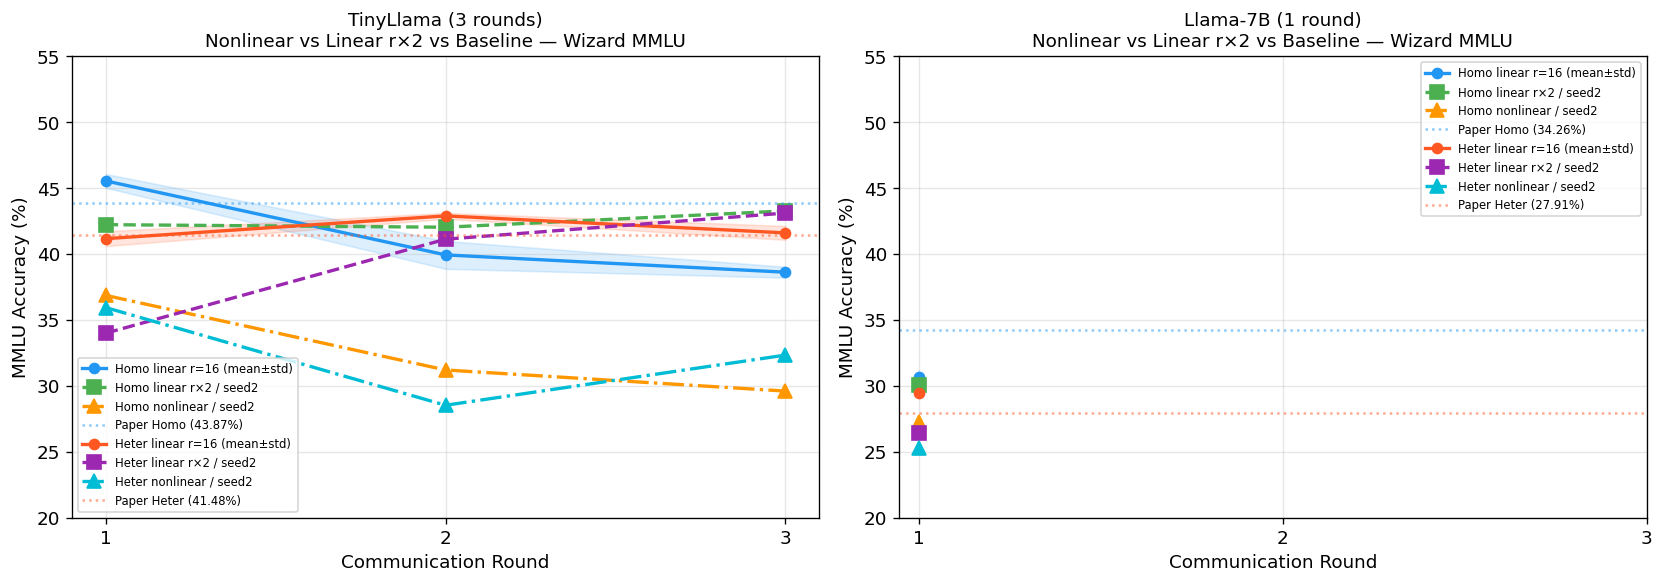

Figure saved: exp2_training_curves.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_base = {'homo': '#2196F3', 'heter': '#FF5722'}
colors_exp1 = {'homo': '#4CAF50', 'heter': '#9C27B0'}
colors_exp2 = {'homo': '#FF9800', 'heter': '#00BCD4'}

for ax, model, model_label in zip(
        axes,
        ['tinyllama', 'llama'],
        ['TinyLlama (3 rounds)', 'Llama-7B (1 round)']):
    for setting in ['homo', 'heter']:
        key = f'{model}_{setting}'
        c_base = colors_base[setting]
        c_exp1 = colors_exp1[setting]
        c_exp2 = colors_exp2[setting]
        lbl    = setting.capitalize()

        # baseline: mean ± std across seeds 0,1,2
        all_base = np.array([seed_results[key][s] for s in SEEDS if s in seed_results[key]])
        base_mean = all_base.mean(axis=0)
        base_std  = all_base.std(axis=0, ddof=1)
        rounds_base = np.arange(1, base_mean.shape[0] + 1)
        ax.plot(rounds_base, base_mean, 'o-', color=c_base, linewidth=2,
                label=f'{lbl} linear r=16 (mean±std)')
        ax.fill_between(rounds_base, base_mean - base_std, base_mean + base_std,
                        color=c_base, alpha=0.15)

        # Exp1: linear r×2, seed 2
        if exp1_results[key] is not None:
            rounds_exp1 = np.arange(1, len(exp1_results[key]) + 1)
            ax.plot(rounds_exp1, exp1_results[key], 's--', color=c_exp1,
                    linewidth=2, markersize=8, label=f'{lbl} linear r×2 / seed2')

        # Exp2: nonlinear r=16, seed 2
        if exp2_results[key] is not None:
            rounds_exp2 = np.arange(1, len(exp2_results[key]) + 1)
            ax.plot(rounds_exp2, exp2_results[key], '^-.', color=c_exp2,
                    linewidth=2, markersize=8, label=f'{lbl} nonlinear / seed2')

        # paper target
        ax.axhline(paper_wiz[key], color=c_base, linestyle=':', alpha=0.5,
                   label=f'Paper {lbl} ({paper_wiz[key]:.2f}%)')

    ax.set_title(f'{model_label}\nNonlinear vs Linear r×2 vs Baseline — Wizard MMLU', fontsize=11)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('MMLU Accuracy (%)')
    ax.set_xticks(range(1, 4))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(20, 55)

plt.tight_layout()
plt.savefig('exp2_training_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved: exp2_training_curves.png")

## 30. Bar Chart: Paper / Exp1 (Linear r×2) / Exp2 (Nonlinear)

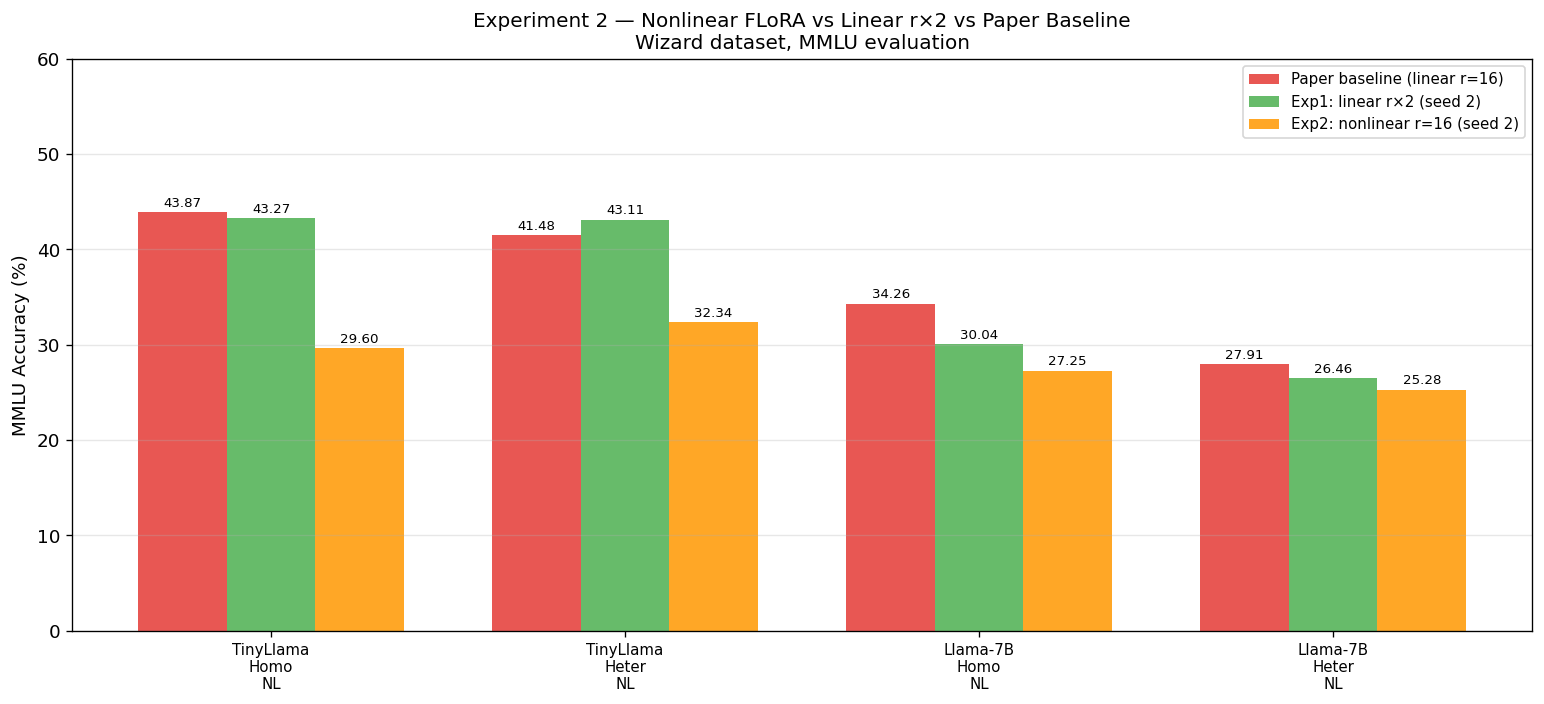

Figure saved: exp2_bar_chart.png


In [31]:
fig, ax = plt.subplots(figsize=(13, 6))

keys    = list(EXP2_EXPERIMENTS.keys())
x       = np.arange(len(keys))
width   = 0.25
xlabels = [EXP2_LABELS[k].replace(' ', '\n') for k in keys]

paper_vals  = [paper_wiz[k] for k in keys]
exp1_finals = [exp1_results[k][-1] if exp1_results[k] else float('nan') for k in keys]
exp2_finals = [exp2_results[k][-1] if exp2_results[k] else float('nan') for k in keys]

bars1 = ax.bar(x - width, paper_vals,  width, color='#E53935', alpha=0.85,
               label='Paper baseline (linear r=16)')
bars2 = ax.bar(x,         exp1_finals, width, color='#4CAF50', alpha=0.85,
               label='Exp1: linear r×2 (seed 2)')
bars3 = ax.bar(x + width, exp2_finals, width, color='#FF9800', alpha=0.85,
               label='Exp2: nonlinear r=16 (seed 2)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    if not np.isnan(bar.get_height()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars3:
    if not np.isnan(bar.get_height()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('MMLU Accuracy (%)')
ax.set_title('Experiment 2 — Nonlinear FLoRA vs Linear r×2 vs Paper Baseline\nWizard dataset, MMLU evaluation',
             fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 60)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_bar_chart.png', bbox_inches='tight')
plt.show()
print("Figure saved: exp2_bar_chart.png")

## 31. Full Summary Table — Experiment 2

In [32]:
exp2_info = {
    'tinyllama_homo':  ('TinyLlama Homo',  3, 'r=16 (nonlinear)'),
    'tinyllama_heter': ('TinyLlama Heter', 3, '[64,32,16,16,8,8,4,4,4,4] (nonlinear)'),
    'llama_homo':      ('Llama-7B Homo',   1, 'r=16 (nonlinear)'),
    'llama_heter':     ('Llama-7B Heter',  1, '[64,32,16,16,8,8,4,4,4,4] (nonlinear)'),
}

print("Exp2 Nonlinear FLoRA Summary — Wizard dataset, MMLU accuracy (%)")
print("=" * 115)
print(f"{'Experiment':<20} {'Config':<38} {'Rds':>4}  {'Paper':>7} {'Exp1 r×2':>9} {'Exp2 NL':>8} {'NL−base':>8} {'NL−Exp1':>8}")
print("-" * 115)

for k, (name, rounds, config) in exp2_info.items():
    exp2_final  = exp2_results[k][-1] if exp2_results[k] else float('nan')
    exp1_final  = exp1_results[k][-1] if exp1_results[k] else float('nan')
    paper_val   = paper_wiz[k]
    base_mean   = stats[k]['mean']
    delta_base  = exp2_final - base_mean
    delta_exp1  = exp2_final - exp1_final
    print(f"{name:<20} {config:<38} {rounds:>4}  {paper_val:>7.2f} {exp1_final:>9.2f} {exp2_final:>8.2f} {delta_base:>+8.2f} {delta_exp1:>+8.2f}")

print("=" * 115)
print("NL−base = Exp2 nonlinear final − paper baseline mean  (positive → NL > linear r=16)")
print("NL−Exp1 = Exp2 nonlinear final − Exp1 linear r×2     (positive → NL beats doubled rank)")

Exp2 Nonlinear FLoRA Summary — Wizard dataset, MMLU accuracy (%)
Experiment           Config                                  Rds    Paper  Exp1 r×2  Exp2 NL  NL−base  NL−Exp1
-------------------------------------------------------------------------------------------------------------------
TinyLlama Homo       r=16 (nonlinear)                          3    43.87     43.27    29.60    -9.02   -13.67
TinyLlama Heter      [64,32,16,16,8,8,4,4,4,4] (nonlinear)     3    41.48     43.11    32.34    -9.27   -10.78
Llama-7B Homo        r=16 (nonlinear)                          1    34.26     30.04    27.25    -3.45    -2.78
Llama-7B Heter       [64,32,16,16,8,8,4,4,4,4] (nonlinear)     1    27.91     26.46    25.28    -4.20    -1.18
NL−base = Exp2 nonlinear final − paper baseline mean  (positive → NL > linear r=16)
NL−Exp1 = Exp2 nonlinear final − Exp1 linear r×2     (positive → NL beats doubled rank)


## 32. Interpretation — Experiment 2

In [33]:
print("Interpretation — Experiment 2: Nonlinear FLoRA vs Doubled Rank")
print("=" * 70)

for key in EXP2_EXPERIMENTS:
    exp2_final = exp2_results[key][-1] if exp2_results[key] else float('nan')
    exp1_final = exp1_results[key][-1] if exp1_results[key] else float('nan')
    base_mean  = stats[key]['mean']
    base_std   = stats[key]['std']
    ci_lo = base_mean - 2 * base_std
    ci_hi = base_mean + 2 * base_std
    delta_base = exp2_final - base_mean
    delta_exp1 = exp2_final - exp1_final

    print(f"\n{EXP2_LABELS[key]}:")
    print(f"  Nonlinear (Exp2): {exp2_final:.2f}%")
    print(f"  Linear r×2 (Exp1): {exp1_final:.2f}%")
    print(f"  Baseline mean:    {base_mean:.2f}% ± {base_std:.2f}%  95% CI [{ci_lo:.2f}, {ci_hi:.2f}]")
    print(f"  NL vs baseline:   {delta_base:+.2f}pp")
    print(f"  NL vs linear r×2: {delta_exp1:+.2f}pp  →  nonlinear {'BEATS' if delta_exp1 > 0 else 'LOSES TO'} doubled rank")

print("\n" + "=" * 70)
print("\nNote: Both Exp1 and Exp2 use only seed 2. Conclusions are preliminary.")
print("The key question: does B·σ(A·x) match B·A at 2× rank with the same compute budget?")

Interpretation — Experiment 2: Nonlinear FLoRA vs Doubled Rank

TinyLlama Homo NL:
  Nonlinear (Exp2): 29.60%
  Linear r×2 (Exp1): 43.27%
  Baseline mean:    38.63% ± 0.41%  95% CI [37.81, 39.45]
  NL vs baseline:   -9.02pp
  NL vs linear r×2: -13.67pp  →  nonlinear LOSES TO doubled rank

TinyLlama Heter NL:
  Nonlinear (Exp2): 32.34%
  Linear r×2 (Exp1): 43.11%
  Baseline mean:    41.61% ± 0.52%  95% CI [40.56, 42.66]
  NL vs baseline:   -9.27pp
  NL vs linear r×2: -10.78pp  →  nonlinear LOSES TO doubled rank

Llama-7B Homo NL:
  Nonlinear (Exp2): 27.25%
  Linear r×2 (Exp1): 30.04%
  Baseline mean:    30.70% ± 0.47%  95% CI [29.76, 31.65]
  NL vs baseline:   -3.45pp
  NL vs linear r×2: -2.78pp  →  nonlinear LOSES TO doubled rank

Llama-7B Heter NL:
  Nonlinear (Exp2): 25.28%
  Linear r×2 (Exp1): 26.46%
  Baseline mean:    29.47% ± 0.26%  95% CI [28.95, 29.99]
  NL vs baseline:   -4.20pp
  NL vs linear r×2: -1.18pp  →  nonlinear LOSES TO doubled rank


Note: Both Exp1 and Exp2 use only